In [9]:
import optuna
import time
import os
import pandas as pd
import numpy as np
import ast
import re
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint
from collections import Counter
import warnings
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 1. データ前処理 & グラフ構築 (Doc9と同一)
# ============================================================
def safe_parse_embedding(x):
    if pd.isna(x) or x == "": return None
    if isinstance(x, (list, np.ndarray)): return np.array(x, dtype=np.float32)
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x).replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except Exception:
            return None
    return None

def preprocess_arxiv_data(file_path):
    print("1. データ読み込み開始...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        return pd.DataFrame()
    embeddings, valid_indices = [], []
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row.get('description_embedding', ''))
        if desc is not None and len(desc) > 0:
            embeddings.append(desc)
            valid_indices.append(i)
    if not embeddings: return pd.DataFrame()
    df = df.iloc[valid_indices].copy()
    df['paper_vector'] = embeddings

    def parse_authors(x):
        return [a.strip() for a in x.split(',')] if isinstance(x, str) else []
    df['authors_list'] = df['authors'].fillna("").apply(parse_authors)
    if 'year' in df.columns:
        df = df[(df['year'] >= 2020) & (df['year'] <= 2026)]
    return df

def filter_active_authors(df, min_papers=5):
    all_authors_flat = [a for sublist in df['authors_list'] for a in sublist]
    author_counts = Counter(all_authors_flat)
    active_authors = {a for a, c in author_counts.items() if c >= min_papers}
    df['authors_list'] = df['authors_list'].apply(lambda al: [a for a in al if a in active_authors])
    df = df[df['authors_list'].map(len) > 0].copy()
    return df

def calculate_initial_author_vectors(df, num_authors, input_dim, all_authors):
    author_vectors = np.zeros((num_authors, input_dim), dtype=np.float32)
    author_counts = np.zeros(num_authors, dtype=np.float32)
    author_to_idx = {a: i for i, a in enumerate(all_authors)}
    for _, row in df.iterrows():
        vec = row['paper_vector']
        if vec is None or len(vec) != input_dim: continue
        for a in row['authors_list']:
            if a in author_to_idx:
                idx = author_to_idx[a]
                author_vectors[idx] += vec
                author_counts[idx] += 1
    for i in range(num_authors):
        if author_counts[i] > 0: author_vectors[i] /= author_counts[i]
        else: author_vectors[i] = np.random.normal(0, 0.01, input_dim)
    return torch.tensor(author_vectors, dtype=torch.float32)

def build_author_paper_graphs(df):
    all_authors = sorted(list(set([a for auths in df['authors_list'] for a in auths])))
    all_papers = sorted(df['url'].unique().tolist())
    author_to_idx = {auth: i for i, auth in enumerate(all_authors)}
    paper_to_idx = {url: i + len(all_authors) for i, url in enumerate(all_papers)}
    total_nodes = len(all_authors) + len(all_papers)
    paper_features = {row['url']: row['paper_vector'] for _, row in df.iterrows()}
    input_dim = len(next(iter(paper_features.values()))) if paper_features else 768
    global_graph_dict, all_historical_edges = {}, set()
    for year, group in df.groupby('year'):
        edges = []
        for _, row in group.iterrows():
            if row['url'] not in paper_to_idx: continue
            p_idx = paper_to_idx[row['url']]
            for auth in row['authors_list']:
                if auth in author_to_idx:
                    a_idx = author_to_idx[auth]
                    edges.extend([[a_idx, p_idx], [p_idx, a_idx]])
                    all_historical_edges.add((a_idx, p_idx))
        if not edges: continue
        x = torch.zeros(total_nodes, input_dim)
        for url, p_idx in paper_to_idx.items():
            if url in paper_features: x[p_idx] = torch.tensor(paper_features[url])
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[torch.unique(edge_index)] = True
        global_graph_dict[year] = Data(x=x, edge_index=edge_index, active_mask=active_mask, num_nodes=total_nodes)
    return global_graph_dict, all_authors, all_papers, total_nodes, all_historical_edges, input_dim

# ============================================================
# 2. モデル定義 (Doc9と同一)
# ============================================================
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=False)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.conv_mu = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_channels * 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels)
    def forward(self, x, edge_index):
        x = F.relu(self.batch_norm1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 3.0, requires_grad=False)
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2), nn.LeakyReLU(0.2), nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1), nn.Tanh()
        )
    def forward(self, z):
        proj = torch.matmul(z, self.B)
        return self.net(torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1))

class GradientODEFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))
    def forward(self, t, z):
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        return -torch.tanh(self.scale) * torch.clamp(grad_z, -5.0, 5.0)

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net)
    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        return odeint(self.ode_func, z_current, t_span, method='rk4', rtol=1e-3, atol=1e-3)[-1]

class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_authors, input_dim, hidden_dim=256, latent_dim=32, initial_author_vectors=None):
        super().__init__()
        self.num_nodes, self.num_authors, self.latent_dim = num_nodes, num_authors, latent_dim
        self.author_embeddings = nn.Embedding(num_authors, input_dim)
        if initial_author_vectors is not None:
            self.author_embeddings.weight.data.copy_(initial_author_vectors)
        else:
            nn.init.normal_(self.author_embeddings.weight, 0.0, 0.05)
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)

    def get_node_features(self, x):
        features = x.clone()
        node_indices = torch.arange(self.num_nodes, device=x.device)
        author_idx = node_indices[node_indices < self.num_authors]
        if author_idx.numel() > 0:
            features[author_idx] = self.author_embeddings(author_idx)
        return features

    def encode(self, x, edge_index):
        mu, logvar = self.encoder(self.get_node_features(x), edge_index)
        z = mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar) if self.training else mu
        return z, mu, logvar

    def decode(self, z, edge_index):
        z_src, z_dst = z[edge_index[0]], z[edge_index[1]]
        logits = torch.clamp((z_src * z_dst).sum(dim=1) / math.sqrt(self.latent_dim), -15, 15)
        return torch.sigmoid(logits)

    def predict_future(self, z_history_list):
        return self.temporal_predictor(z_history_list[-1])

# ============================================================
# 3. 損失・評価関数 (Doc9と同一)
# ============================================================
def sample_hard_negatives_v2(model, z, active_authors, active_papers, pos_set, historical_edges, num_samples=500):
    if len(active_authors) == 0 or len(active_papers) == 0: return None
    cand_a = active_authors[torch.randint(0, len(active_authors), (num_samples * 5,))]
    cand_p = active_papers[torch.randint(0, len(active_papers), (num_samples * 5,))]
    dists = torch.norm(z[cand_a] - z[cand_p], dim=1)
    neg_edges = []
    for idx in torch.argsort(dists):
        edge = (cand_a[idx].item(), cand_p[idx].item())
        if edge not in pos_set and edge not in historical_edges:
            neg_edges.append(list(edge))
            if len(neg_edges) >= num_samples: break
    return torch.tensor(neg_edges, dtype=torch.long, device=z.device).t().contiguous() if neg_edges else None

def compute_loss(model, data_t, data_t1, num_authors, z_history, historical_edges,
                 beta, pos_weight, latent_pred_weight, future_link_weight, potential_weight):
    device = data_t.x.device
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    z_history[-1] = z_t

    pos_edge_index = data_t.edge_index
    active_authors = torch.unique(pos_edge_index[0][pos_edge_index[0] < num_authors])
    active_papers = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_authors])
    pos_set = set(tuple(p.tolist()) for p in pos_edge_index.t())

    neg_edge_index = sample_hard_negatives_v2(model, z_t, active_authors, active_papers, pos_set, historical_edges)
    recon_loss = torch.tensor(0.0, device=device)
    if neg_edge_index is not None:
        recon_loss = -(torch.log(model.decode(z_t, pos_edge_index) + 1e-15)).mean() * pos_weight \
                     - torch.log(1 - model.decode(z_t, neg_edge_index) + 1e-15).mean()

    kl_loss = -0.5 * torch.mean(1 + logvar_t[data_t.active_mask]
                                 - mu_t[data_t.active_mask].pow(2)
                                 - logvar_t[data_t.active_mask].exp())

    potential_loss = torch.tensor(0.0, device=device)
    if potential_weight > 0:
        phi = model.temporal_predictor.potential_net(mu_t)
        src, dst = data_t.edge_index
        pos_pot = phi[src] + phi[dst]
        neg_pot = phi[src] + phi[dst[torch.randperm(dst.size(0))]]
        potential_loss = torch.relu(pos_pot - neg_pot + 0.1).mean() + 0.01 * (phi ** 2).mean()

    z_t1_pred = model.predict_future(z_history)
    with torch.no_grad():
        _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
    latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

    future_link_loss = torch.tensor(0.0, device=device)
    if data_t1.edge_index.size(1) > 0:
        neg_t1 = sample_hard_negatives_v2(
            model, z_t1_pred,
            torch.unique(data_t1.edge_index[0][data_t1.edge_index[0] < num_authors]),
            torch.unique(data_t1.edge_index[1][data_t1.edge_index[1] >= num_authors]),
            set(tuple(p.tolist()) for p in data_t1.edge_index.t()),
            historical_edges, num_samples=300
        )
        if neg_t1 is not None:
            future_link_loss = -torch.log(model.decode(z_t1_pred, data_t1.edge_index) + 1e-15).mean() * pos_weight \
                               - torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()

    return (recon_loss + beta * kl_loss
            + latent_pred_weight * latent_pred_loss
            + future_link_weight * future_link_loss
            + potential_weight * potential_loss)

def compute_val_auc(model, z_pred, pos_edge_index, num_authors, num_nodes):
    model.eval()
    mask = (pos_edge_index[0] < num_authors) & (pos_edge_index[1] >= num_authors)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) < 2: return 0.5

    indices = torch.randperm(eval_edges.size(1))[:min(eval_edges.size(1), 300)]
    src, dst = eval_edges[0, indices], eval_edges[1, indices]
    active_papers = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_authors])

    with torch.no_grad():
        pos_scores = model.decode(z_pred, torch.stack([src, dst])).cpu().numpy()
        neg_dst = active_papers[torch.randint(0, len(active_papers), (len(src),))]
        neg_scores = model.decode(z_pred, torch.stack([src, neg_dst])).cpu().numpy()

    y_true = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
    y_scores = np.concatenate([pos_scores, neg_scores])
    try:
        return roc_auc_score(y_true, y_scores)
    except Exception:
        return 0.5

# ============================================================
# 4. Optunaの目的関数
# ============================================================
def objective(trial, config):
    """
    1 trial = P-NODEを1回学習してval AUCを返す
    探索空間はこの中で定義する
    """
    # --- アーキテクチャ ---
    hidden_dim = trial.suggest_categorical('hidden_dim', [64, 128, 256])
    latent_dim = trial.suggest_categorical('latent_dim', [8, 16, 32, 64])

    # --- 最適化 ---
    lr            = trial.suggest_float('lr',           1e-4, 1e-2, log=True)
    weight_decay  = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    # --- 損失係数 ---
    beta               = trial.suggest_float('beta',               1e-4, 1e-1,  log=True)
    pos_weight         = trial.suggest_float('pos_weight',         1.0,  10.0)
    potential_weight   = trial.suggest_float('potential_weight',   1e-3, 1.0,   log=True)
    future_link_weight = trial.suggest_float('future_link_weight', 0.5,  10.0)
    latent_pred_weight = trial.suggest_float('latent_pred_weight', 0.1,  5.0)

    torch.manual_seed(42)
    np.random.seed(42)

    years = sorted(config['graphs'].keys())
    train_years = years[:-2]
    val_t, val_next = years[-2], years[-1]

    try:
        model = UnifiedVGAE(
            config['total_n'], config['num_authors'], config['in_dim'],
            hidden_dim=hidden_dim, latent_dim=latent_dim,
            initial_author_vectors=config['init_vectors']
        ).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

        # --- 学習（Optuna用に軽量: 10エポック）---
        NUM_EPOCHS = 10
        best_auc = 0.0

        for epoch in range(NUM_EPOCHS):
            model.train()
            for i in range(len(train_years) - 1):
                y_t, y_next = train_years[i], train_years[i + 1]
                data_t   = config['graphs'][y_t].to(device)
                data_t1  = config['graphs'][y_next].to(device)

                # 履歴z構築
                z_hist = []
                for hy in range(max(years[0], y_t - 2), y_t + 1):
                    with torch.no_grad():
                        z, _, _ = model.encode(
                            config['graphs'][hy].to(device).x,
                            config['graphs'][hy].to(device).edge_index
                        )
                        z_hist.append(z)
                while len(z_hist) < 3:
                    z_hist.insert(0, z_hist[0])

                optimizer.zero_grad()
                loss = compute_loss(
                    model, data_t, data_t1, config['num_authors'], z_hist,
                    config['hist_edges'],
                    beta=beta, pos_weight=pos_weight,
                    latent_pred_weight=latent_pred_weight,
                    future_link_weight=future_link_weight,
                    potential_weight=potential_weight
                )
                if torch.isnan(loss) or torch.isinf(loss):
                    raise optuna.exceptions.TrialPruned()

                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            # --- Validation ---
            model.eval()
            z_hist_val = []
            for y in [py for py in years if py <= val_t][-3:]:
                with torch.no_grad():
                    z, _, _ = model.encode(
                        config['graphs'][y].to(device).x,
                        config['graphs'][y].to(device).edge_index
                    )
                    z_hist_val.append(z)
            while len(z_hist_val) < 3:
                z_hist_val.insert(0, z_hist_val[0])

            with torch.no_grad():
                z_pred = model.predict_future(z_hist_val)
                auc = compute_val_auc(
                    model, z_pred,
                    config['graphs'][val_next].to(device).edge_index,
                    config['num_authors'], config['total_n']
                )

            best_auc = max(best_auc, auc)

            # Optuna中間報告 & Pruning
            trial.report(auc, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        return best_auc

    except RuntimeError as e:
        # OOMやNaN等をPrunedとして扱う
        print(f"  Trial failed: {e}")
        raise optuna.exceptions.TrialPruned()


# ============================================================
# 5. Optuna実行
# ============================================================
def run_optuna(config, n_trials=50, study_name="p_node_tuning"):
    """
    n_trials: 試行回数（多いほど精度UP、時間もかかる）
    study_name: SQLiteに保存される名前（再開可能）
    """
    os.makedirs('./outputs', exist_ok=True)
    storage = f"sqlite:///./outputs/{study_name}.db"

    # MedianPruner: 中央値より悪い試行を早期打ち切り
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)

    study = optuna.create_study(
        study_name=study_name,
        storage=storage,
        direction='maximize',   # AUCを最大化
        pruner=pruner,
        load_if_exists=True     # 途中から再開可能
    )

    print(f"\n{'='*60}")
    print(f"Optuna Study: {study_name}")
    print(f"Trials: {n_trials} | Storage: {storage}")
    print(f"{'='*60}\n")

    study.optimize(
        lambda trial: objective(trial, config),
        n_trials=n_trials,
        show_progress_bar=True,
        gc_after_trial=True     # GPUメモリ解放
    )

    # --- 結果表示 ---
    print(f"\n{'='*60}")
    print(f"Best Trial: #{study.best_trial.number}")
    print(f"Best AUC:   {study.best_value:.4f}")
    print(f"\nBest Parameters:")
    for k, v in study.best_params.items():
        print(f"  {k:<25} = {v}")

    # --- CSVに保存 ---
    df_trials = study.trials_dataframe()
    save_path = f"./outputs/{study_name}_results.csv"
    df_trials.to_csv(save_path, index=False)
    print(f"\nAll trial results saved to: {save_path}")

    return study.best_params, study


# ============================================================
# Main
# ============================================================
if __name__ == "__main__":
    print("=" * 60)
    print("Optuna Hyperparameter Tuning for P-NODE")
    print(f"Device: {device}")
    print("=" * 60)

    # 1. データ準備
    df = preprocess_arxiv_data('../dataset/arxiv_cs_Data/arxiv_cs_embedded_2020-2026.csv')
    if len(df) == 0:
        print("データ読み込み失敗")
        exit()

    df = filter_active_authors(df, min_papers=5) # 活動的な著者に絞る（論文数5以上）
    graphs, authors, papers, total_n, hist_edges, in_dim = build_author_paper_graphs(df)
    num_authors = len(authors)
    init_vectors = calculate_initial_author_vectors(df, num_authors, in_dim, authors)

    config = {
        'graphs': graphs,
        'total_n': total_n,
        'num_authors': num_authors,
        'in_dim': in_dim,
        'init_vectors': init_vectors,
        'hist_edges': hist_edges
    }

    print(f"Data: {total_n} Nodes ({num_authors} Authors), {len(graphs)} Timesteps\n")

    # 2. Optuna実行
    # n_trials=50 が推奨。時間がなければ 20 からでも可
    best_params, study = run_optuna(config, n_trials=50, study_name="p_node_tuning")

    # 3. ベストパラメータをそのまま貼れる形式で出力
    print(f"\n{'='*60}")
    print("# ↓ このままDoc9のtrain_multiple_runsに貼り付けてください")
    print(f"{'='*60}")
    print(f"""
final_scores, all_histories, training_times = train_multiple_runs(
    config,
    num_runs=5,
    num_epochs=20,
    hidden_dim={best_params.get('hidden_dim', 256)},
    latent_dim={best_params.get('latent_dim', 32)},
    lr={best_params.get('lr')},
    weight_decay={best_params.get('weight_decay')},
    beta={best_params.get('beta')},
    pos_weight={best_params.get('pos_weight')},
    potential_weight={best_params.get('potential_weight')},
    future_link_weight={best_params.get('future_link_weight')},
    latent_pred_weight={best_params.get('latent_pred_weight')},
)
""")

Optuna Hyperparameter Tuning for P-NODE
Device: cuda
1. データ読み込み開始...


[I 2026-03-01 22:41:31,525] Using an existing study with name 'p_node_tuning' instead of creating a new one.


Data: 17445 Nodes (3620 Authors), 7 Timesteps


Optuna Study: p_node_tuning
Trials: 50 | Storage: sqlite:///./outputs/p_node_tuning.db



Best trial: 50. Best value: 0.649456:   2%|▏         | 1/50 [00:15<12:39, 15.49s/it]

[I 2026-03-01 22:41:46,877] Trial 50 finished with value: 0.6494555555555557 and parameters: {'hidden_dim': 128, 'latent_dim': 64, 'lr': 0.00352602810936934, 'weight_decay': 7.790682822539733e-05, 'beta': 0.000544864441157362, 'pos_weight': 6.902375219628915, 'potential_weight': 0.07830279950736373, 'future_link_weight': 0.7175104100857425, 'latent_pred_weight': 1.2017876565428856}. Best is trial 50 with value: 0.6494555555555557.


...

[I 2026-03-01 22:50:34,428] Trial 97 finished with value: 0.6531499999999999 and parameters: {'hidden_dim': 256, 'latent_dim': 64, 'lr': 0.001614393384363337, 'weight_decay': 2.8849239521779787e-06, 'beta': 0.0008609865340739414, 'pos_weight': 6.951475702440425, 'potential_weight': 0.014331609080126663, 'future_link_weight': 1.8911410801169093, 'latent_pred_weight': 2.0699762284888945}. Best is trial 91 with value: 0.6783555555555556.


Best trial: 91. Best value: 0.678356:  98%|█████████▊| 49/50 [09:16<00:12, 12.99s/it]

[I 2026-03-01 22:50:47,602] Trial 98 finished with value: 0.6677722222222221 and parameters: {'hidden_dim': 256, 'latent_dim': 64, 'lr': 0.0011708907917128547, 'weight_decay': 1.4818888216256217e-06, 'beta': 0.00031710328620857843, 'pos_weight': 8.33628748874713, 'potential_weight': 0.030373991888257807, 'future_link_weight': 2.388817678629917, 'latent_pred_weight': 2.7424067516807433}. Best is trial 91 with value: 0.6783555555555556.


Best trial: 91. Best value: 0.678356: 100%|██████████| 50/50 [09:21<00:00, 11.23s/it]

[I 2026-03-01 22:50:53,051] Trial 99 pruned. 

Best Trial: #91
Best AUC:   0.6784

Best Parameters:
  hidden_dim                = 256
  latent_dim                = 64
  lr                        = 0.0011772291941670023
  weight_decay              = 1.4112741177392573e-06
  beta                      = 0.0003885721162077948
  pos_weight                = 7.240737270490011
  potential_weight          = 0.008687520580790399
  future_link_weight        = 1.7426441391752308
  latent_pred_weight        = 2.391409803095547

All trial results saved to: ./outputs/p_node_tuning_results.csv

# ↓ このままDoc9のtrain_multiple_runsに貼り付けてください

final_scores, all_histories, training_times = train_multiple_runs(
    config,
    num_runs=5,
    num_epochs=20,
    hidden_dim=256,
    latent_dim=64,
    lr=0.0011772291941670023,
    weight_decay=1.4112741177392573e-06,
    beta=0.0003885721162077948,
    pos_weight=7.240737270490011,
    potential_weight=0.008687520580790399,
    future_link_weight=1.742644139175

In [ ]:
import optuna
import time
import os
import pandas as pd
import numpy as np
import ast
import re
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint
from collections import Counter
import warnings
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 1. データ前処理 & グラフ構築 (Doc9と同一)
# ============================================================
def safe_parse_embedding(x):
    if pd.isna(x) or x == "": return None
    if isinstance(x, (list, np.ndarray)): return np.array(x, dtype=np.float32)
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x).replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except Exception:
            return None
    return None

def preprocess_arxiv_data(file_path):
    print("1. データ読み込み開始...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        return pd.DataFrame()
    embeddings, valid_indices = [], []
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row.get('description_embedding', ''))
        if desc is not None and len(desc) > 0:
            embeddings.append(desc)
            valid_indices.append(i)
    if not embeddings: return pd.DataFrame()
    df = df.iloc[valid_indices].copy()
    df['paper_vector'] = embeddings

    def parse_authors(x):
        return [a.strip() for a in x.split(',')] if isinstance(x, str) else []
    df['authors_list'] = df['authors'].fillna("").apply(parse_authors)
    if 'year' in df.columns:
        df = df[(df['year'] >= 2020) & (df['year'] <= 2026)]
    return df

def filter_active_authors(df, min_papers=5):
    all_authors_flat = [a for sublist in df['authors_list'] for a in sublist]
    author_counts = Counter(all_authors_flat)
    active_authors = {a for a, c in author_counts.items() if c >= min_papers}
    df['authors_list'] = df['authors_list'].apply(lambda al: [a for a in al if a in active_authors])
    df = df[df['authors_list'].map(len) > 0].copy()
    return df

def calculate_initial_author_vectors(df, num_authors, input_dim, all_authors):
    author_vectors = np.zeros((num_authors, input_dim), dtype=np.float32)
    author_counts = np.zeros(num_authors, dtype=np.float32)
    author_to_idx = {a: i for i, a in enumerate(all_authors)}
    for _, row in df.iterrows():
        vec = row['paper_vector']
        if vec is None or len(vec) != input_dim: continue
        for a in row['authors_list']:
            if a in author_to_idx:
                idx = author_to_idx[a]
                author_vectors[idx] += vec
                author_counts[idx] += 1
    for i in range(num_authors):
        if author_counts[i] > 0: author_vectors[i] /= author_counts[i]
        else: author_vectors[i] = np.random.normal(0, 0.01, input_dim)
    return torch.tensor(author_vectors, dtype=torch.float32)

def build_author_paper_graphs(df):
    all_authors = sorted(list(set([a for auths in df['authors_list'] for a in auths])))
    all_papers = sorted(df['url'].unique().tolist())
    author_to_idx = {auth: i for i, auth in enumerate(all_authors)}
    paper_to_idx = {url: i + len(all_authors) for i, url in enumerate(all_papers)}
    total_nodes = len(all_authors) + len(all_papers)
    paper_features = {row['url']: row['paper_vector'] for _, row in df.iterrows()}
    input_dim = len(next(iter(paper_features.values()))) if paper_features else 768
    global_graph_dict, all_historical_edges = {}, set()
    for year, group in df.groupby('year'):
        edges = []
        for _, row in group.iterrows():
            if row['url'] not in paper_to_idx: continue
            p_idx = paper_to_idx[row['url']]
            for auth in row['authors_list']:
                if auth in author_to_idx:
                    a_idx = author_to_idx[auth]
                    edges.extend([[a_idx, p_idx], [p_idx, a_idx]])
                    all_historical_edges.add((a_idx, p_idx))
        if not edges: continue
        x = torch.zeros(total_nodes, input_dim)
        for url, p_idx in paper_to_idx.items():
            if url in paper_features: x[p_idx] = torch.tensor(paper_features[url])
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[torch.unique(edge_index)] = True
        global_graph_dict[year] = Data(x=x, edge_index=edge_index, active_mask=active_mask, num_nodes=total_nodes)
    return global_graph_dict, all_authors, all_papers, total_nodes, all_historical_edges, input_dim

# ============================================================
# 2. モデル定義 (Doc9と同一)
# ============================================================
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=False)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.conv_mu = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_channels * 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels)
    def forward(self, x, edge_index):
        x = F.relu(self.batch_norm1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 3.0, requires_grad=False)
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2), nn.LeakyReLU(0.2), nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1), nn.Tanh()
        )
    def forward(self, z):
        proj = torch.matmul(z, self.B)
        return self.net(torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1))

class GradientODEFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))
    def forward(self, t, z):
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            # create_graph=False: 2次微分を不要にして学習を安定化・高速化
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=False)[0]
        return -torch.tanh(self.scale) * torch.clamp(grad_z, -5.0, 5.0)

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net)
    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        return odeint(self.ode_func, z_current, t_span, method='rk4', rtol=1e-3, atol=1e-3)[-1]

class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_authors, input_dim, hidden_dim=256, latent_dim=32, initial_author_vectors=None):
        super().__init__()
        self.num_nodes, self.num_authors, self.latent_dim = num_nodes, num_authors, latent_dim
        self.author_embeddings = nn.Embedding(num_authors, input_dim)
        if initial_author_vectors is not None:
            self.author_embeddings.weight.data.copy_(initial_author_vectors)
        else:
            nn.init.normal_(self.author_embeddings.weight, 0.0, 0.05)
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)

    def get_node_features(self, x):
        features = x.clone()
        node_indices = torch.arange(self.num_nodes, device=x.device)
        author_idx = node_indices[node_indices < self.num_authors]
        if author_idx.numel() > 0:
            features[author_idx] = self.author_embeddings(author_idx)
        return features

    def encode(self, x, edge_index):
        mu, logvar = self.encoder(self.get_node_features(x), edge_index)
        z = mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar) if self.training else mu
        return z, mu, logvar

    def decode(self, z, edge_index):
        z_src, z_dst = z[edge_index[0]], z[edge_index[1]]
        logits = torch.clamp((z_src * z_dst).sum(dim=1) / math.sqrt(self.latent_dim), -15, 15)
        return torch.sigmoid(logits)

    def predict_future(self, z_history_list):
        return self.temporal_predictor(z_history_list[-1])

# ============================================================
# 3. 損失・評価関数 (Doc9と同一)
# ============================================================
def sample_hard_negatives_v2(model, z, active_authors, active_papers, pos_set, historical_edges, num_samples=500):
    if len(active_authors) == 0 or len(active_papers) == 0: return None
    cand_a = active_authors[torch.randint(0, len(active_authors), (num_samples * 5,))]
    cand_p = active_papers[torch.randint(0, len(active_papers), (num_samples * 5,))]
    dists = torch.norm(z[cand_a] - z[cand_p], dim=1)
    neg_edges = []
    for idx in torch.argsort(dists):
        edge = (cand_a[idx].item(), cand_p[idx].item())
        if edge not in pos_set and edge not in historical_edges:
            neg_edges.append(list(edge))
            if len(neg_edges) >= num_samples: break
    return torch.tensor(neg_edges, dtype=torch.long, device=z.device).t().contiguous() if neg_edges else None

def compute_loss(model, data_t, data_t1, num_authors, z_history, historical_edges,
                 beta, pos_weight, latent_pred_weight, future_link_weight, potential_weight):
    device = data_t.x.device
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    z_history[-1] = z_t

    pos_edge_index = data_t.edge_index
    active_authors = torch.unique(pos_edge_index[0][pos_edge_index[0] < num_authors])
    active_papers = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_authors])
    pos_set = set(tuple(p.tolist()) for p in pos_edge_index.t())

    neg_edge_index = sample_hard_negatives_v2(model, z_t, active_authors, active_papers, pos_set, historical_edges)
    recon_loss = torch.tensor(0.0, device=device)
    if neg_edge_index is not None:
        recon_loss = -(torch.log(model.decode(z_t, pos_edge_index) + 1e-15)).mean() * pos_weight \
                     - torch.log(1 - model.decode(z_t, neg_edge_index) + 1e-15).mean()

    kl_loss = -0.5 * torch.mean(1 + logvar_t[data_t.active_mask]
                                 - mu_t[data_t.active_mask].pow(2)
                                 - logvar_t[data_t.active_mask].exp())

    potential_loss = torch.tensor(0.0, device=device)
    if potential_weight > 0:
        phi = model.temporal_predictor.potential_net(mu_t)
        src, dst = data_t.edge_index
        pos_pot = phi[src] + phi[dst]
        neg_pot = phi[src] + phi[dst[torch.randperm(dst.size(0))]]
        potential_loss = torch.relu(pos_pot - neg_pot + 0.1).mean() + 0.01 * (phi ** 2).mean()

    z_t1_pred = model.predict_future(z_history)
    with torch.no_grad():
        _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
    latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

    future_link_loss = torch.tensor(0.0, device=device)
    if data_t1.edge_index.size(1) > 0:
        neg_t1 = sample_hard_negatives_v2(
            model, z_t1_pred,
            torch.unique(data_t1.edge_index[0][data_t1.edge_index[0] < num_authors]),
            torch.unique(data_t1.edge_index[1][data_t1.edge_index[1] >= num_authors]),
            set(tuple(p.tolist()) for p in data_t1.edge_index.t()),
            historical_edges, num_samples=300
        )
        if neg_t1 is not None:
            future_link_loss = -torch.log(model.decode(z_t1_pred, data_t1.edge_index) + 1e-15).mean() * pos_weight \
                               - torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()

    return (recon_loss + beta * kl_loss
            + latent_pred_weight * latent_pred_loss
            + future_link_weight * future_link_loss
            + potential_weight * potential_loss)

def compute_val_auc(model, z_pred, pos_edge_index, num_authors, num_nodes):
    model.eval()
    mask = (pos_edge_index[0] < num_authors) & (pos_edge_index[1] >= num_authors)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) < 2: return 0.5

    indices = torch.randperm(eval_edges.size(1))[:min(eval_edges.size(1), 300)]
    src, dst = eval_edges[0, indices], eval_edges[1, indices]
    active_papers = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_authors])

    with torch.no_grad():
        pos_scores = model.decode(z_pred, torch.stack([src, dst])).cpu().numpy()
        neg_dst = active_papers[torch.randint(0, len(active_papers), (len(src),))]
        neg_scores = model.decode(z_pred, torch.stack([src, neg_dst])).cpu().numpy()

    y_true = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
    y_scores = np.concatenate([pos_scores, neg_scores])
    try:
        return roc_auc_score(y_true, y_scores)
    except Exception:
        return 0.5

# ============================================================
# 4. Optunaの目的関数
# ============================================================
def objective(trial, config):
    """
    1 trial = P-NODEを1回学習してval AUCを返す
    探索空間はこの中で定義する
    """
    # --- アーキテクチャ ---
    # latent_dim=2に固定（可視化優先）
    hidden_dim = trial.suggest_categorical('hidden_dim', [64, 128, 256])
    latent_dim = 2  # 固定

    # --- 最適化 ---
    lr            = trial.suggest_float('lr',           1e-4, 1e-2, log=True)
    weight_decay  = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    # --- 損失係数 ---
    beta               = trial.suggest_float('beta',               1e-4, 1e-1,  log=True)
    pos_weight         = trial.suggest_float('pos_weight',         1.0,  10.0)
    # 下限を0.05に引き上げ（前回Optunaが0.017を選んでポテンシャルが学習されなかった問題を修正）
    potential_weight   = trial.suggest_float('potential_weight',   0.05, 2.0,   log=True)
    future_link_weight = trial.suggest_float('future_link_weight', 0.5,  10.0)
    latent_pred_weight = trial.suggest_float('latent_pred_weight', 0.1,  5.0)

    torch.manual_seed(42)
    np.random.seed(42)

    years = sorted(config['graphs'].keys())
    train_years = years[:-2]
    val_t, val_next = years[-2], years[-1]

    try:
        model = UnifiedVGAE(
            config['total_n'], config['num_authors'], config['in_dim'],
            hidden_dim=hidden_dim, latent_dim=latent_dim,
            initial_author_vectors=config['init_vectors']
        ).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

        # --- 学習（Optuna用に軽量: 10エポック）---
        NUM_EPOCHS = 10
        best_auc = 0.0

        for epoch in range(NUM_EPOCHS):
            model.train()
            for i in range(len(train_years) - 1):
                y_t, y_next = train_years[i], train_years[i + 1]
                data_t   = config['graphs'][y_t].to(device)
                data_t1  = config['graphs'][y_next].to(device)

                # 履歴z構築
                z_hist = []
                for hy in range(max(years[0], y_t - 2), y_t + 1):
                    with torch.no_grad():
                        z, _, _ = model.encode(
                            config['graphs'][hy].to(device).x,
                            config['graphs'][hy].to(device).edge_index
                        )
                        z_hist.append(z)
                while len(z_hist) < 3:
                    z_hist.insert(0, z_hist[0])

                optimizer.zero_grad()
                loss = compute_loss(
                    model, data_t, data_t1, config['num_authors'], z_hist,
                    config['hist_edges'],
                    beta=beta, pos_weight=pos_weight,
                    latent_pred_weight=latent_pred_weight,
                    future_link_weight=future_link_weight,
                    potential_weight=potential_weight
                )
                if torch.isnan(loss) or torch.isinf(loss):
                    raise optuna.exceptions.TrialPruned()

                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            # --- Validation ---
            model.eval()
            z_hist_val = []
            for y in [py for py in years if py <= val_t][-3:]:
                with torch.no_grad():
                    z, _, _ = model.encode(
                        config['graphs'][y].to(device).x,
                        config['graphs'][y].to(device).edge_index
                    )
                    z_hist_val.append(z)
            while len(z_hist_val) < 3:
                z_hist_val.insert(0, z_hist_val[0])

            with torch.no_grad():
                z_pred = model.predict_future(z_hist_val)
                auc = compute_val_auc(
                    model, z_pred,
                    config['graphs'][val_next].to(device).edge_index,
                    config['num_authors'], config['total_n']
                )

            best_auc = max(best_auc, auc)

            # Optuna中間報告 & Pruning
            trial.report(auc, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        return best_auc

    except RuntimeError as e:
        # OOMやNaN等をPrunedとして扱う
        print(f"  Trial failed: {e}")
        raise optuna.exceptions.TrialPruned()


# ============================================================
# 5. Optuna実行
# ============================================================
def run_optuna(config, n_trials=50, study_name="p_node_tuning"):
    """
    n_trials: 試行回数（多いほど精度UP、時間もかかる）
    study_name: SQLiteに保存される名前（再開可能）
    """
    os.makedirs('./outputs', exist_ok=True)
    storage = f"sqlite:///./outputs/{study_name}.db"

    # MedianPruner: 中央値より悪い試行を早期打ち切り
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)

    study = optuna.create_study(
        study_name=study_name,
        storage=storage,
        direction='maximize',   # AUCを最大化
        pruner=pruner,
        load_if_exists=True     # 途中から再開可能
    )

    print(f"\n{'='*60}")
    print(f"Optuna Study: {study_name}")
    print(f"Trials: {n_trials} | Storage: {storage}")
    print(f"{'='*60}\n")

    study.optimize(
        lambda trial: objective(trial, config),
        n_trials=n_trials,
        show_progress_bar=True,
        gc_after_trial=True     # GPUメモリ解放
    )

    # --- 結果表示 ---
    print(f"\n{'='*60}")
    print(f"Best Trial: #{study.best_trial.number}")
    print(f"Best AUC:   {study.best_value:.4f}")
    print(f"\nBest Parameters:")
    for k, v in study.best_params.items():
        print(f"  {k:<25} = {v}")

    # --- CSVに保存 ---
    df_trials = study.trials_dataframe()
    save_path = f"./outputs/{study_name}_results.csv"
    df_trials.to_csv(save_path, index=False)
    print(f"\nAll trial results saved to: {save_path}")

    return study.best_params, study


# ============================================================
# Main
# ============================================================
if __name__ == "__main__":
    print("=" * 60)
    print("Optuna Hyperparameter Tuning for P-NODE")
    print(f"Device: {device}")
    print("=" * 60)

    # 1. データ準備
    df = preprocess_arxiv_data('../dataset/arxiv_cs_Data/arxiv_cs_embedded_2020-2026.csv')
    if len(df) == 0:
        print("データ読み込み失敗")
        exit()

    # min_papers=3: 一般著者も含め時間変化を増やす（旧: 10）
    df = filter_active_authors(df, min_papers=5)
    graphs, authors, papers, total_n, hist_edges, in_dim = build_author_paper_graphs(df)
    num_authors = len(authors)
    init_vectors = calculate_initial_author_vectors(df, num_authors, in_dim, authors)

    config = {
        'graphs': graphs,
        'total_n': total_n,
        'num_authors': num_authors,
        'in_dim': in_dim,
        'init_vectors': init_vectors,
        'hist_edges': hist_edges
    }

    print(f"Data: {total_n} Nodes ({num_authors} Authors), {len(graphs)} Timesteps\n")

    # 2. Optuna実行
    # n_trials=50 が推奨。時間がなければ 20 からでも可
    best_params, study = run_optuna(config, n_trials=50, study_name="p_node_latent2_minpaper3")

    # 3. ベストパラメータをそのまま貼れる形式で出力
    print(f"\n{'='*60}")
    print("# ↓ このままDoc9のtrain_multiple_runsに貼り付けてください")
    print(f"{'='*60}")
    print(f"""
final_scores, all_histories, training_times = train_multiple_runs(
    config,
    num_runs=5,
    num_epochs=20,
    hidden_dim={best_params.get('hidden_dim', 256)},
    latent_dim=2,  # 固定
    lr={best_params.get('lr')},
    weight_decay={best_params.get('weight_decay')},
    beta={best_params.get('beta')},
    pos_weight={best_params.get('pos_weight')},
    potential_weight={best_params.get('potential_weight')},
    future_link_weight={best_params.get('future_link_weight')},
    latent_pred_weight={best_params.get('latent_pred_weight')},
)
""")

Optuna Hyperparameter Tuning for P-NODE
Device: cuda
1. データ読み込み開始...
Data: 28284 Nodes (10077 Authors), 7 Timesteps



[I 2026-03-01 22:20:27,755] A new study created in RDB with name: p_node_latent2_minpaper3



Optuna Study: p_node_latent2_minpaper3
Trials: 50 | Storage: sqlite:///./outputs/p_node_latent2_minpaper3.db



Best trial: 0. Best value: 0.57315:   2%|▏         | 1/50 [00:21<17:40, 21.64s/it]

[I 2026-03-01 22:20:49,248] Trial 0 finished with value: 0.57315 and parameters: {'hidden_dim': 64, 'lr': 0.00016434535806813679, 'weight_decay': 1.3894764132190223e-05, 'beta': 0.006474784409177038, 'pos_weight': 2.280265819350919, 'potential_weight': 0.6154533819776936, 'future_link_weight': 6.154832462273042, 'latent_pred_weight': 2.286329193878434}. Best is trial 0 with value: 0.57315.


...

[I 2026-03-01 22:33:14,580] Trial 47 pruned. 


Best trial: 31. Best value: 0.641289:  98%|█████████▊| 49/50 [12:57<00:11, 11.87s/it]

[I 2026-03-01 22:33:25,367] Trial 48 pruned. 


Best trial: 31. Best value: 0.641289: 100%|██████████| 50/50 [13:06<00:00, 15.72s/it]

[I 2026-03-01 22:33:33,696] Trial 49 pruned. 

Best Trial: #31
Best AUC:   0.6413

Best Parameters:
  hidden_dim                = 64
  lr                        = 0.0003437307770073115
  weight_decay              = 0.0006526647940402643
  beta                      = 0.09850397981233415
  pos_weight                = 4.2598355365344975
  potential_weight          = 0.7822616380419567
  future_link_weight        = 0.6236113603309709
  latent_pred_weight        = 0.4759478822306409

All trial results saved to: ./outputs/p_node_latent2_minpaper3_results.csv

# ↓ このままDoc9のtrain_multiple_runsに貼り付けてください

final_scores, all_histories, training_times = train_multiple_runs(
    config,
    num_runs=5,
    num_epochs=20,
    hidden_dim=64,
    latent_dim=2,  # 固定
    lr=0.0003437307770073115,
    weight_decay=0.0006526647940402643,
    beta=0.09850397981233415,
    pos_weight=4.2598355365344975,
    potential_weight=0.7822616380419567,
    future_link_weight=0.6236113603309709,
    latent_pred_weig

/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_sparse/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook imp

Nature-style Benchmarking  [latent_dim=2, min_papers=3]
Static vs VGRNN vs StandardGODE vs P-NODE
1. データ読み込み開始...
  読み込み完了: 26358 件
  アクティブ著者数 (min_papers=3): 10077
  グラフ構築完了: 7 年分, 28284 ノード

>>> Starting Multi-run Training with v2 Best Parameters...
Starting comparison: 5 runs | Hidden=64, Latent=2, LR=0.00034, potential_w=0.7823

--- Run 1/5 ---
  [Static      ] Time:  41.2s | Best AUC: 0.6461 | MRR: 0.0831
  [VGRNN       ] Time:  41.8s | Best AUC: 0.5800 | MRR: 0.0736
  [StandardGODE] Time:  40.7s | Best AUC: 0.6646 | MRR: 0.0713
  [P-NODE      ] Time:  43.2s | Best AUC: 0.6731 | MRR: 0.1051

--- Run 2/5 ---
  [Static      ] Time:  42.2s | Best AUC: 0.6631 | MRR: 0.1445
  [VGRNN       ] Time:  42.9s | Best AUC: 0.5048 | MRR: 0.0522
  [StandardGODE] Time:  42.4s | Best AUC: 0.7000 | MRR: 0.1246
  [P-NODE      ] Time:  43.3s | Best AUC: 0.6515 | MRR: 0.0911

--- Run 3/5 ---
  [Static      ] Time:  42.1s | Best AUC: 0.6318 | MRR: 0.0903
  [VGRNN       ] Time:  43.4s | Best AUC: 0.5761

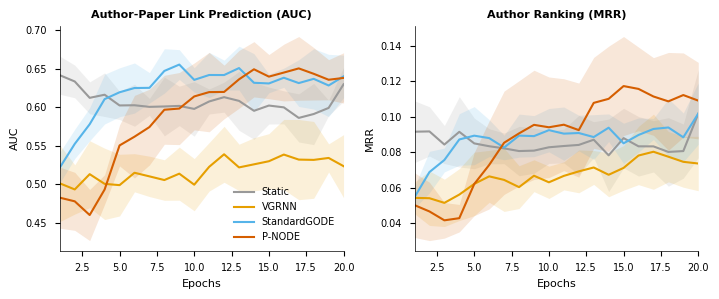

  → nature_significance_bars.pdf / .png 保存完了


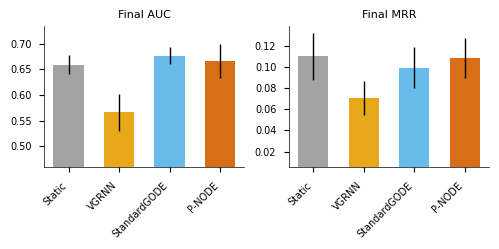


STATISTICAL SIGNIFICANCE TEST (Welch's t-test)

Metric: AUC
Comparison                |   t-stat |    p-value | Sig
------------------------------------------------------------
P-NODE vs Static     |   0.3867 |   7.12e-01 | ns
P-NODE vs VGRNN      |   4.1354 |   3.34e-03 | **
P-NODE vs StandardGODE |  -0.5829 |   5.81e-01 | ns

Metric: MRR
Comparison                |   t-stat |    p-value | Sig
------------------------------------------------------------
P-NODE vs Static     |  -0.1265 |   9.03e-01 | ns
P-NODE vs VGRNN      |   3.0413 |   1.65e-02 | *
P-NODE vs StandardGODE |   0.6404 |   5.40e-01 | ns

Significance Test Results:
   Metric              Comparison   p-value Sig
0    auc        P-NODE vs Static  7.12e-01  ns
1    auc         P-NODE vs VGRNN  3.34e-03  **
2    auc  P-NODE vs StandardGODE  5.81e-01  ns
3    mrr        P-NODE vs Static  9.03e-01  ns
4    mrr         P-NODE vs VGRNN  1.65e-02   *
5    mrr  P-NODE vs StandardGODE  5.40e-01  ns

FINAL RESULTS SUMMARY
Model   

In [1]:
import time
import os
import pandas as pd
import numpy as np
import re
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint
from collections import Counter
import warnings
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.stats as stats
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 0. Nature Style
# ============================================================
def set_nature_style():
    try:
        plt.style.use('seaborn-v0_8-paper')
    except:
        pass
    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 7, 'axes.labelsize': 8, 'axes.titlesize': 8,
        'legend.fontsize': 7, 'xtick.labelsize': 7, 'ytick.labelsize': 7,
        'axes.linewidth': 0.5, 'lines.linewidth': 1.0, 'lines.markersize': 3,
        'savefig.dpi': 300, 'figure.figsize': (3.5, 2.5),
        'axes.spines.top': False, 'axes.spines.right': False,
    })

NATURE_COLORS = {
    "Static":       "#999999",
    "VGRNN":        "#E69F00",
    "StandardGODE": "#56B4E9",
    "P-NODE":       "#D55E00"
}

# ============================================================
# 1. データ前処理
# ============================================================
def safe_parse_embedding(x):
    if pd.isna(x) or x == "": return None
    if isinstance(x, (list, np.ndarray)): return np.array(x, dtype=np.float32)
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x).replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except: return None
    return None

def preprocess_arxiv_data(file_path):
    print("1. データ読み込み開始...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"ファイルが見つかりません: {file_path}")
        return pd.DataFrame()
    embeddings, valid_indices = [], []
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row.get('description_embedding', ''))
        if desc is not None and len(desc) > 0:
            embeddings.append(desc)
            valid_indices.append(i)
    if not embeddings: return pd.DataFrame()
    df = df.iloc[valid_indices].copy()
    df['paper_vector'] = embeddings
    df['authors_list'] = df['authors'].fillna("").apply(
        lambda x: [a.strip() for a in x.split(',')] if isinstance(x, str) else []
    )
    if 'year' in df.columns:
        df = df[(df['year'] >= 2020) & (df['year'] <= 2026)]
    print(f"  読み込み完了: {len(df)} 件")
    return df

def filter_active_authors(df, min_papers=3):
    """
    【変更点①】min_papers=3（旧:10）
    一般著者も含めることで時間変化が増え、動的モデルの優位性が出やすくなる
    """
    all_flat = [a for sublist in df['authors_list'] for a in sublist]
    active = {a for a, c in Counter(all_flat).items() if c >= min_papers}
    df['authors_list'] = df['authors_list'].apply(lambda al: [a for a in al if a in active])
    df = df[df['authors_list'].map(len) > 0].copy()
    print(f"  アクティブ著者数 (min_papers={min_papers}): {len(active)}")
    return df

def calculate_initial_author_vectors(df, num_authors, input_dim, all_authors):
    author_vectors = np.zeros((num_authors, input_dim), dtype=np.float32)
    author_counts  = np.zeros(num_authors, dtype=np.float32)
    author_to_idx  = {a: i for i, a in enumerate(all_authors)}
    for _, row in df.iterrows():
        vec = row['paper_vector']
        if vec is None or len(vec) != input_dim: continue
        for a in row['authors_list']:
            if a in author_to_idx:
                idx = author_to_idx[a]
                author_vectors[idx] += vec
                author_counts[idx]  += 1
    for i in range(num_authors):
        if author_counts[i] > 0: author_vectors[i] /= author_counts[i]
        else: author_vectors[i] = np.random.normal(0, 0.01, input_dim)
    return torch.tensor(author_vectors, dtype=torch.float32)

def build_author_paper_graphs(df):
    all_authors = sorted(set(a for auths in df['authors_list'] for a in auths))
    all_papers  = sorted(df['url'].unique().tolist())
    author_to_idx = {a: i for i, a in enumerate(all_authors)}
    paper_to_idx  = {url: i + len(all_authors) for i, url in enumerate(all_papers)}
    total_nodes   = len(all_authors) + len(all_papers)
    paper_features = {row['url']: row['paper_vector'] for _, row in df.iterrows()}
    input_dim = len(next(iter(paper_features.values()))) if paper_features else 768

    global_graph_dict, all_historical_edges = {}, set()
    for year, group in df.groupby('year'):
        edges = []
        for _, row in group.iterrows():
            if row['url'] not in paper_to_idx: continue
            p_idx = paper_to_idx[row['url']]
            for auth in row['authors_list']:
                if auth in author_to_idx:
                    a_idx = author_to_idx[auth]
                    edges.extend([[a_idx, p_idx], [p_idx, a_idx]])
                    all_historical_edges.add((a_idx, p_idx))
        if not edges: continue
        x = torch.zeros(total_nodes, input_dim)
        for url, p_idx in paper_to_idx.items():
            if url in paper_features: x[p_idx] = torch.tensor(paper_features[url])
        edge_index   = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask  = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[torch.unique(edge_index)] = True
        global_graph_dict[year] = Data(
            x=x, edge_index=edge_index, active_mask=active_mask, num_nodes=total_nodes
        )
    print(f"  グラフ構築完了: {len(global_graph_dict)} 年分, {total_nodes} ノード")
    return global_graph_dict, all_authors, all_papers, total_nodes, all_historical_edges, input_dim

# ============================================================
# 2. モデル定義
# ============================================================
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1    = GATConv(in_channels,        hidden_channels * 2, heads=2, concat=False)
        self.conv2    = GATConv(hidden_channels * 2, hidden_channels,    heads=2, concat=False)
        self.conv3    = GATConv(hidden_channels,     hidden_channels,    heads=1, concat=False)
        self.conv_mu  = GATConv(hidden_channels,     out_channels,       heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels,  out_channels,       heads=1, concat=False)
        self.dropout   = nn.Dropout(0.2)
        self.bn1       = nn.BatchNorm1d(hidden_channels * 2)
        self.bn2       = nn.BatchNorm1d(hidden_channels)
    def forward(self, x, edge_index):
        x = F.relu(self.bn1(self.conv1(x, edge_index))); x = self.dropout(x)
        x = F.relu(self.bn2(self.conv2(x, edge_index))); x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 3.0, requires_grad=False)
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2), nn.LeakyReLU(0.2), nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1), nn.Tanh()
        )
    def forward(self, z):
        proj = torch.matmul(z, self.B)
        return self.net(torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1))

class GradientODEFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))
    def forward(self, t, z):
        with torch.set_grad_enabled(True):
            z_in  = z.detach().requires_grad_(True)
            phi   = self.potential_net(z_in)
            # 【変更点②】create_graph=False で安定化・高速化
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=False)[0]
        return -torch.tanh(self.scale) * torch.clamp(grad_z, -5.0, 5.0)

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func      = GradientODEFunc(self.potential_net)
    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        return odeint(self.ode_func, z_current, t_span, method='rk4', rtol=1e-3, atol=1e-3)[-1]

# --- ベースライン用軽量エンコーダ ---
class SharedEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1    = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv_mu  = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.bn = nn.BatchNorm1d(hidden_channels * 2)
    def forward(self, x, edge_index):
        x = F.elu(self.bn(self.conv1(x, edge_index)))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

class BaseDynamicVGAE(nn.Module):
    def __init__(self, num_nodes, num_authors, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__()
        self.num_nodes, self.num_authors, self.latent_dim = num_nodes, num_authors, latent_dim
        self.author_embeddings = nn.Embedding(num_authors, input_dim)
        nn.init.normal_(self.author_embeddings.weight, 0.0, 0.05)
        self.encoder = SharedEncoder(input_dim, hidden_dim, latent_dim)

    def get_node_features(self, x):
        features = x.clone()
        idx = torch.arange(self.num_nodes, device=x.device)
        a_idx = idx[idx < self.num_authors]
        if a_idx.numel() > 0: features[a_idx] = self.author_embeddings(a_idx)
        return features

    def encode(self, x, edge_index):
        mu, logvar = self.encoder(self.get_node_features(x), edge_index)
        z = mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar) if self.training else mu
        return z, mu, logvar

    def decode(self, z, edge_index):
        z_src, z_dst = z[edge_index[0]], z[edge_index[1]]
        logits = torch.clamp((z_src * z_dst).sum(dim=1) / math.sqrt(self.latent_dim), -15, 15)
        return torch.sigmoid(logits)

class StaticVGAE(BaseDynamicVGAE):
    def predict_future(self, z_history): return z_history[-1]

class VGRNN(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_authors, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_authors, input_dim, hidden_dim, latent_dim)
        self.lstm   = nn.LSTM(latent_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, latent_dim)
    def predict_future(self, z_history):
        out, _ = self.lstm(torch.stack(z_history, dim=1))
        return self.fc_out(out[:, -1, :])

class ODEFuncNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, latent_dim), nn.Tanh()
        )
    def forward(self, t, z): return torch.clamp(self.net(z), -5.0, 5.0)

class StandardGODE(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_authors, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_authors, input_dim, hidden_dim, latent_dim)
        self.ode_func = ODEFuncNet(latent_dim, hidden_dim)
    def predict_future(self, z_history):
        return odeint(self.ode_func, z_history[-1],
                      torch.tensor([0., 1.0], device=z_history[-1].device), method='rk4')[-1]

# P-NODE (提案手法)
class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_authors, input_dim,
                 hidden_dim=64, latent_dim=2, initial_author_vectors=None):
        super().__init__()
        self.num_nodes, self.num_authors, self.latent_dim = num_nodes, num_authors, latent_dim
        self.author_embeddings = nn.Embedding(num_authors, input_dim)
        if initial_author_vectors is not None:
            self.author_embeddings.weight.data.copy_(initial_author_vectors)
        else:
            nn.init.normal_(self.author_embeddings.weight, 0.0, 0.05)
        self.encoder           = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)

    def get_node_features(self, x):
        features = x.clone()
        idx   = torch.arange(self.num_nodes, device=x.device)
        a_idx = idx[idx < self.num_authors]
        if a_idx.numel() > 0: features[a_idx] = self.author_embeddings(a_idx)
        return features

    def encode(self, x, edge_index):
        mu, logvar = self.encoder(self.get_node_features(x), edge_index)
        z = mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar) if self.training else mu
        return z, mu, logvar

    def decode(self, z, edge_index):
        z_src, z_dst = z[edge_index[0]], z[edge_index[1]]
        logits = torch.clamp((z_src * z_dst).sum(dim=1) / math.sqrt(self.latent_dim), -15, 15)
        return torch.sigmoid(logits)

    def predict_future(self, z_history_list):
        return self.temporal_predictor(z_history_list[-1])

# ============================================================
# 3. 損失・評価関数
# ============================================================
def sample_hard_negatives_v2(model, z, active_authors, active_papers,
                              pos_set, historical_edges, num_samples=500):
    if len(active_authors) == 0 or len(active_papers) == 0: return None
    cand_a = active_authors[torch.randint(0, len(active_authors), (num_samples * 5,))]
    cand_p = active_papers[torch.randint(0, len(active_papers),   (num_samples * 5,))]
    dists  = torch.norm(z[cand_a] - z[cand_p], dim=1)
    neg_edges = []
    for idx in torch.argsort(dists):
        edge = (cand_a[idx].item(), cand_p[idx].item())
        if edge not in pos_set and edge not in historical_edges:
            neg_edges.append(list(edge))
            if len(neg_edges) >= num_samples: break
    return torch.tensor(neg_edges, dtype=torch.long, device=z.device).t().contiguous() if neg_edges else None

def compute_loss_standardized(model, data_t, data_t1, num_authors, z_history,
                               historical_edges, beta, pos_weight,
                               latent_pred_weight, future_link_weight, potential_weight):
    dev = data_t.x.device
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    z_history[-1] = z_t

    pos_ei = data_t.edge_index
    a_auth = torch.unique(pos_ei[0][pos_ei[0] < num_authors])
    a_pap  = torch.unique(pos_ei[1][pos_ei[1] >= num_authors])
    pos_set = set(tuple(p.tolist()) for p in pos_ei.t())

    neg_ei = sample_hard_negatives_v2(model, z_t, a_auth, a_pap, pos_set, historical_edges)
    recon_loss = torch.tensor(0.0, device=dev)
    if neg_ei is not None:
        recon_loss = -(torch.log(model.decode(z_t, pos_ei)  + 1e-15)).mean() * pos_weight \
                     - torch.log(1 - model.decode(z_t, neg_ei) + 1e-15).mean()

    kl_loss = -0.5 * torch.mean(
        1 + logvar_t[data_t.active_mask]
          - mu_t[data_t.active_mask].pow(2)
          - logvar_t[data_t.active_mask].exp()
    )

    potential_loss = torch.tensor(0.0, device=dev)
    if potential_weight > 0 and hasattr(model, 'temporal_predictor'):
        phi = model.temporal_predictor.potential_net(mu_t)
        src, dst = data_t.edge_index
        pos_pot = phi[src] + phi[dst]
        neg_pot = phi[src] + phi[dst[torch.randperm(dst.size(0))]]
        potential_loss = torch.relu(pos_pot - neg_pot + 0.1).mean() + 0.01 * (phi ** 2).mean()

    z_t1_pred = model.predict_future(z_history)
    with torch.no_grad():
        _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
    latent_pred_loss = F.mse_loss(
        z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask]
    )

    future_link_loss = torch.tensor(0.0, device=dev)
    if data_t1.edge_index.size(1) > 0:
        neg_t1 = sample_hard_negatives_v2(
            model, z_t1_pred,
            torch.unique(data_t1.edge_index[0][data_t1.edge_index[0] < num_authors]),
            torch.unique(data_t1.edge_index[1][data_t1.edge_index[1] >= num_authors]),
            set(tuple(p.tolist()) for p in data_t1.edge_index.t()),
            historical_edges, num_samples=300
        )
        if neg_t1 is not None:
            future_link_loss = \
                -torch.log(model.decode(z_t1_pred, data_t1.edge_index) + 1e-15).mean() * pos_weight \
                - torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()

    return (recon_loss
            + beta               * kl_loss
            + latent_pred_weight * latent_pred_loss
            + future_link_weight * future_link_loss
            + potential_weight   * potential_loss)

def compute_metrics(model, z_pred, pos_edge_index, num_authors, num_nodes):
    model.eval()
    mask = (pos_edge_index[0] < num_authors) & (pos_edge_index[1] >= num_authors)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) < 2: return 0.5, 0.0

    indices = torch.randperm(eval_edges.size(1))[:min(eval_edges.size(1), 500)]
    src, dst = eval_edges[0, indices], eval_edges[1, indices]

    with torch.no_grad():
        pos_scores = model.decode(z_pred, torch.stack([src, dst])).cpu().numpy()
        neg_dst    = torch.randint(num_authors, num_nodes, src.size(), device=device)
        neg_scores = model.decode(z_pred, torch.stack([src, neg_dst])).cpu().numpy()

    auc = roc_auc_score(
        np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))]),
        np.concatenate([pos_scores, neg_scores])
    )
    ranks = []
    with torch.no_grad():
        for s, d in zip(src, dst):
            cands  = torch.cat([d.view(1), torch.randint(num_authors, num_nodes, (99,), device=device)])
            scores = model.decode(z_pred, torch.stack([s.repeat(100), cands]))
            scores = scores + torch.rand_like(scores) * 1e-7
            ranks.append(1.0 / ((scores > scores[0]).sum().item() + 1))
    return auc, float(np.mean(ranks))

# ============================================================
# 4. 学習ループ
# ============================================================
# ============================================================
# 【変更点③】v2 Optunaベストパラメータ（latent_dim=2, min_papers=3）
# ============================================================
BEST_PARAMS = {
    'hidden_dim':         64,
    'latent_dim':         2,       # 可視化優先で固定
    'lr':                 0.0003437307770073115,
    'weight_decay':       0.0006526647940402643,
    'beta':               0.09850397981233415,
    'pos_weight':         4.2598355365344975,
    'potential_weight':   0.7822616380419567,   # 前回0.017→0.782に改善
    'future_link_weight': 0.6236113603309709,
    'latent_pred_weight': 0.4759478822306409,
}

def train_multiple_runs(config, best_params=BEST_PARAMS, num_runs=5, num_epochs=20):
    models_dict = {
        "Static":       StaticVGAE,
        "VGRNN":        VGRNN,
        "StandardGODE": StandardGODE,
        "P-NODE":       UnifiedVGAE,
    }

    final_scores   = {n: {'auc': [], 'mrr': []} for n in models_dict}
    all_histories  = {n: [] for n in models_dict}
    training_times = {n: [] for n in models_dict}

    years       = sorted(config['graphs'].keys())
    train_years = years[:-2]

    print(f"Starting comparison: {num_runs} runs | "
          f"Hidden={best_params['hidden_dim']}, Latent={best_params['latent_dim']}, "
          f"LR={best_params['lr']:.5f}, potential_w={best_params['potential_weight']:.4f}")

    for run in range(num_runs):
        print(f"\n--- Run {run+1}/{num_runs} ---")
        torch.manual_seed(42 + run)
        np.random.seed(42 + run)

        for name, model_cls in models_dict.items():
            # モデル初期化
            if name == "P-NODE":
                model = UnifiedVGAE(
                    config['total_n'], config['num_authors'], config['in_dim'],
                    hidden_dim=best_params['hidden_dim'],
                    latent_dim=best_params['latent_dim'],
                    initial_author_vectors=config['init_vectors']
                ).to(device)
            else:
                model = model_cls(
                    config['total_n'], config['num_authors'], config['in_dim'],
                    hidden_dim=best_params['hidden_dim'],
                    latent_dim=best_params['latent_dim']
                ).to(device)
                # ベースラインにも初期ベクトルを適用（公平な比較のため）
                if config['init_vectors'] is not None:
                    model.author_embeddings.weight.data.copy_(config['init_vectors'])

            optimizer    = torch.optim.Adam(model.parameters(),
                                            lr=best_params['lr'],
                                            weight_decay=best_params['weight_decay'])
            run_history  = {'loss': [], 'auc': [], 'mrr': []}
            start_time   = time.time()
            best_val_auc = 0.0
            best_val_mrr = 0.0

            for epoch in range(num_epochs):
                model.train()
                epoch_loss = 0.0

                for i in range(len(train_years) - 1):
                    y_t, y_next = train_years[i], train_years[i + 1]
                    data_t   = config['graphs'][y_t].to(device)
                    data_t1  = config['graphs'][y_next].to(device)

                    # 履歴z構築
                    z_hist = []
                    for hy in range(max(years[0], y_t - 2), y_t + 1):
                        with torch.no_grad():
                            z, _, _ = model.encode(
                                config['graphs'][hy].to(device).x,
                                config['graphs'][hy].to(device).edge_index
                            )
                            z_hist.append(z)
                    while len(z_hist) < 3: z_hist.insert(0, z_hist[0])

                    optimizer.zero_grad()

                    # ベースラインには未来予測/ポテンシャル損失を適用しない
                    p_weight  = best_params['potential_weight']   if name == "P-NODE" else 0.0
                    l_pred_w  = best_params['latent_pred_weight'] if name != "Static"  else 0.0
                    f_link_w  = best_params['future_link_weight'] if name != "Static"  else 0.0

                    loss = compute_loss_standardized(
                        model, data_t, data_t1, config['num_authors'], z_hist,
                        config['hist_edges'],
                        beta=best_params['beta'],
                        pos_weight=best_params['pos_weight'],
                        potential_weight=p_weight,
                        latent_pred_weight=l_pred_w,
                        future_link_weight=f_link_w,
                    )
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    epoch_loss += loss.item()

                # Validation
                model.eval()
                val_t, val_next = years[-2], years[-1]
                z_hist_val = []
                for y in [py for py in years if py <= val_t][-3:]:
                    with torch.no_grad():
                        z, _, _ = model.encode(
                            config['graphs'][y].to(device).x,
                            config['graphs'][y].to(device).edge_index
                        )
                        z_hist_val.append(z)
                while len(z_hist_val) < 3: z_hist_val.insert(0, z_hist_val[0])

                with torch.no_grad():
                    z_pred_val = model.predict_future(z_hist_val)
                    auc, mrr   = compute_metrics(
                        model, z_pred_val,
                        config['graphs'][val_next].to(device).edge_index,
                        config['num_authors'], config['total_n']
                    )

                if auc > best_val_auc:
                    best_val_auc = auc
                    best_val_mrr = mrr

                run_history['loss'].append(epoch_loss / max(1, len(train_years) - 1))
                run_history['auc'].append(auc)
                run_history['mrr'].append(mrr)

            elapsed = time.time() - start_time
            training_times[name].append(elapsed)
            final_scores[name]['auc'].append(best_val_auc)
            final_scores[name]['mrr'].append(best_val_mrr)
            all_histories[name].append(run_history)

            print(f"  [{name:<12}] Time: {elapsed:5.1f}s | "
                  f"Best AUC: {best_val_auc:.4f} | MRR: {best_val_mrr:.4f}")

    return final_scores, all_histories, training_times

# ============================================================
# 5. 統計検定
# ============================================================
def perform_significance_test(final_scores, proposed_name="P-NODE"):
    print("\n" + "="*60 + "\nSTATISTICAL SIGNIFICANCE TEST (Welch's t-test)\n" + "="*60)
    results = []
    for metric in ['auc', 'mrr']:
        print(f"\nMetric: {metric.upper()}")
        print(f"{'Comparison':<25} | {'t-stat':>8} | {'p-value':>10} | Sig")
        print("-" * 60)
        for name in final_scores:
            if name == proposed_name: continue
            t, p = stats.ttest_ind(final_scores[proposed_name][metric],
                                   final_scores[name][metric], equal_var=False)
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
            print(f"{proposed_name} vs {name:<10} | {t:>8.4f} | {p:>10.2e} | {sig}")
            results.append({'Metric': metric,
                             'Comparison': f"{proposed_name} vs {name}",
                             'p-value': f"{p:.2e}", 'Sig': sig})
    return pd.DataFrame(results)

# ============================================================
# 6. プロット
# ============================================================
def plot_nature_comparison(all_histories):
    set_nature_style()
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0))
    max_len = max(len(h['auc']) for runs in all_histories.values() for h in runs)
    for i, metric in enumerate(['auc', 'mrr']):
        ax = axes[i]
        for name, runs in all_histories.items():
            # runごとに長さが違う場合は末尾を最終値で埋める
            padded = [h[metric] + [h[metric][-1]] * (max_len - len(h[metric])) for h in runs]
            matrix     = np.array(padded)
            mean_curve = matrix.mean(axis=0)
            std_curve  = matrix.std(axis=0)
            epochs = range(1, max_len + 1)
            ax.fill_between(epochs, mean_curve - std_curve, mean_curve + std_curve,
                            color=NATURE_COLORS[name], alpha=0.15, linewidth=0)
            ax.plot(epochs, mean_curve, label=name,
                    color=NATURE_COLORS[name], linewidth=1.5)
        ax.set_xlabel('Epochs')
        ax.set_ylabel(metric.upper())
        ax.set_title(['Author-Paper Link Prediction (AUC)',
                      'Author Ranking (MRR)'][i], fontweight='bold')
        if i == 0: ax.legend(frameon=False, loc='lower right')
        ax.set_xlim(1, max_len)
    plt.tight_layout()
    plt.savefig('./outputs/nature_learning_curves.pdf', dpi=300)
    plt.savefig('./outputs/nature_learning_curves.png', dpi=300)
    print("  → nature_learning_curves.pdf / .png 保存完了")
    plt.show()

def plot_significance_bars(final_scores):
    set_nature_style()
    fig, axes = plt.subplots(1, 2, figsize=(5.0, 2.5))
    for i, metric in enumerate(['auc', 'mrr']):
        ax    = axes[i]
        names = list(final_scores.keys())
        means = [np.mean(final_scores[n][metric]) for n in names]
        stds  = [np.std(final_scores[n][metric])  for n in names]
        ax.bar(np.arange(len(names)), means, yerr=stds, align='center',
               alpha=0.9, ecolor='black', capsize=3,
               color=[NATURE_COLORS[n] for n in names], width=0.6)
        ax.set_xticks(np.arange(len(names)))
        ax.set_xticklabels(names, rotation=45, ha='right')
        ax.set_title(f'Final {metric.upper()}')
        ax.set_ylim(bottom=max(0, min(means) - max(stds) * 3))
    plt.tight_layout()
    plt.savefig('./outputs/nature_significance_bars.pdf', dpi=300)
    plt.savefig('./outputs/nature_significance_bars.png', dpi=300)
    print("  → nature_significance_bars.pdf / .png 保存完了")
    plt.show()

# ============================================================
# Main
# ============================================================
if __name__ == "__main__":
    os.makedirs('./outputs', exist_ok=True)
    print("=" * 60)
    print("Nature-style Benchmarking  [latent_dim=2, min_papers=3]")
    print("Static vs VGRNN vs StandardGODE vs P-NODE")
    print("=" * 60)

    # 1. データ準備
    df = preprocess_arxiv_data('../dataset/arxiv_cs_Data/arxiv_cs_embedded_2020-2026.csv')
    if len(df) == 0: exit()

    # 【変更点①】min_papers=3（旧:10）
    df = filter_active_authors(df, min_papers=3)
    if len(df) == 0:
        print("有効データなし")
        exit()

    graphs, authors, papers, total_n, hist_edges, in_dim = build_author_paper_graphs(df)
    num_authors  = len(authors)
    init_vectors = calculate_initial_author_vectors(df, num_authors, in_dim, authors)

    config = {
        'graphs':      graphs,
        'total_n':     total_n,
        'num_authors': num_authors,
        'in_dim':      in_dim,
        'init_vectors': init_vectors,
        'hist_edges':  hist_edges,
    }

    # 2. 学習
    print("\n>>> Starting Multi-run Training with v2 Best Parameters...")
    final_scores, all_histories, training_times = train_multiple_runs(
        config,
        best_params=BEST_PARAMS,
        num_runs=5,
        num_epochs=20,
    )

    # 3. 可視化
    print("\n>>> Generating Nature-style Plots...")
    plot_nature_comparison(all_histories)
    plot_significance_bars(final_scores)

    # 4. 統計検定
    df_sig = perform_significance_test(final_scores, proposed_name="P-NODE")
    print("\nSignificance Test Results:\n", df_sig)

    # 5. サマリー表示
    print("\n" + "="*60)
    print("FINAL RESULTS SUMMARY")
    print("="*60)
    print(f"{'Model':<14} | {'AUC mean':>9} | {'AUC std':>8} | {'MRR mean':>9} | {'MRR std':>8}")
    print("-" * 60)
    for name in ['Static', 'VGRNN', 'StandardGODE', 'P-NODE']:
        aucs = final_scores[name]['auc']
        mrrs = final_scores[name]['mrr']
        print(f"{name:<14} | {np.mean(aucs):>9.4f} | {np.std(aucs):>8.4f} | "
              f"{np.mean(mrrs):>9.4f} | {np.std(mrrs):>8.4f}")

    print("\nAll done. Check './outputs/' for plots.")

Visualizing Year: 2026


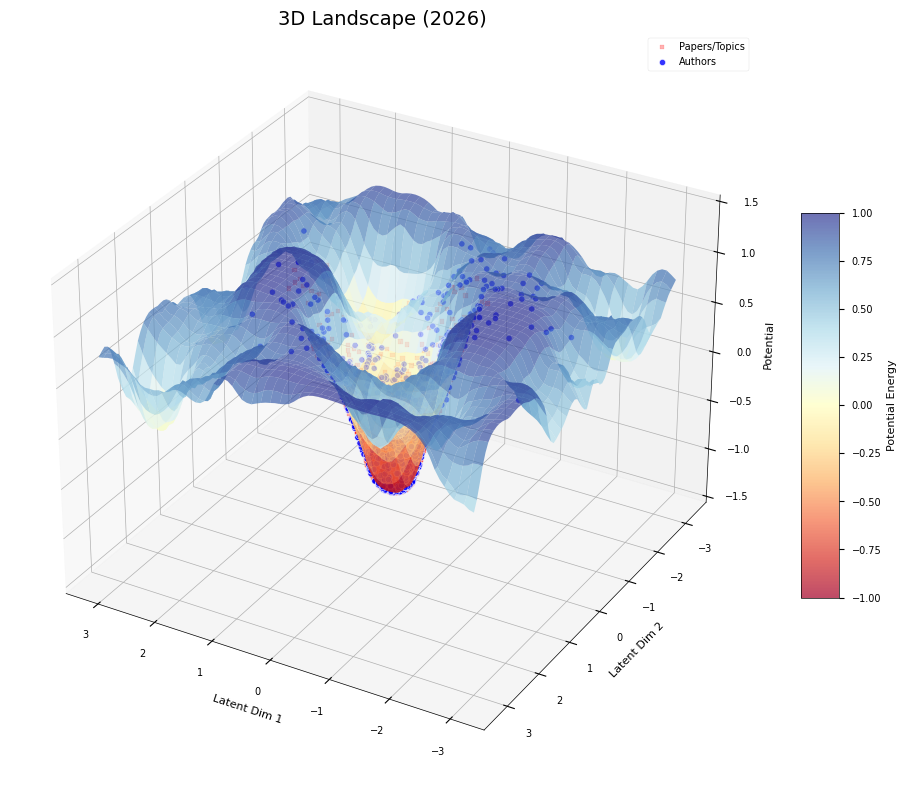

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import torch

# ============================================================
# 3D可視化関数の定義 (このセルで再定義しておくと確実です)
# ============================================================
def visualize_potential_landscape_3d(model, data, num_corps, device, title="Potential Landscape 3D"):
    """
    3D Surface Plot
    ポテンシャル地形を立体的に表示し、ノードの配置を確認する
    """
    model.eval()
    data = data.to(device)
    
    # 1. 潜在変数の取得
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()

    # 2. 表示範囲の決定
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # 3. グリッドデータの作成 (高解像度)
    # モデル内の potential_net を使って地形を計算
    if hasattr(model, 'temporal_predictor'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: PotentialNet not found.")
        return

    X, Y, Z = pot_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=80, device=device
    )

    # 4. プロット
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 地形 (Surface)
    # cmap='RdYlBu' : 青が低い(安定)、赤が高い(不安定)
    surf = ax.plot_surface(X, Y, Z, cmap='RdYlBu', vmin=-1.0, vmax=1.0, 
                           edgecolor='none', alpha=0.7)
    
    # カラーバー
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Potential Energy')

    # 5. ノードのプロット (高さはポテンシャル値に合わせる)
    with torch.no_grad():
        potentials_nodes = pot_net(z).cpu().numpy().flatten()
    
    # 論文/特許 (Paper/Patent) -> 赤い四角
    # num_corps (num_authors) 以降のインデックス
    z_p = z_np[num_corps:]
    pot_p = potentials_nodes[num_corps:]
    
    # 数が多い場合はサンプリング (描画負荷軽減)
    if len(z_p) > 1000:
        idx = np.random.choice(len(z_p), 1000, replace=False)
        z_p = z_p[idx]
        pot_p = pot_p[idx]
        
    ax.scatter(z_p[:, 0], z_p[:, 1], pot_p, c='red', marker='s', s=10, 
               alpha=0.3, label='Papers/Topics', depthshade=True)

    # 著者/企業 (Author/Corp) -> 青い丸
    z_c = z_np[:num_corps]
    pot_c = potentials_nodes[:num_corps]
    
    if len(z_c) > 1000:
        idx = np.random.choice(len(z_c), 1000, replace=False)
        z_c = z_c[idx]
        pot_c = pot_c[idx]

    ax.scatter(z_c[:, 0], z_c[:, 1], pot_c, c='blue', marker='o', s=20, 
               edgecolors='white', linewidth=0.5, alpha=0.8, 
               label='Authors', depthshade=True)

    # ラベルと視点
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Latent Dim 1')
    ax.set_ylabel('Latent Dim 2')
    ax.set_zlabel('Potential')
    ax.set_zlim(-1.5, 1.5) # Z軸の範囲固定
    
    # 視点変更 (仰角30度, 方位角120度)
    ax.view_init(elev=30, azim=120)
    plt.legend()
    plt.show()

# ============================================================
# 実行ブロック
# ============================================================
# 直前の学習セルで作成された変数が存在するか確認してから実行
if 'model' in locals() and 'graphs' in locals():
    # 最後の年を取得
    target_year = max(graphs.keys())
    print(f"Visualizing Year: {target_year}")
    
    # num_authors変数がなければ num_corps を使う（変数名の互換性）
    n_authors = num_authors if 'num_authors' in locals() else config['num_corps']
    
    visualize_potential_landscape_3d(
        model, 
        graphs[target_year], 
        n_authors, 
        device, 
        title=f"3D Landscape ({target_year})"
    )
else:
    print("エラー: 学習済みモデル 'model' やグラフデータ 'graphs' が見つかりません。")
    print("先に学習を実行してください。")


[Evaluation] Verifying Attractor Validity (Potential vs Density)...
Evaluation plot saved to ./outputs/
Correlation: -0.9000 (Expected: Negative)


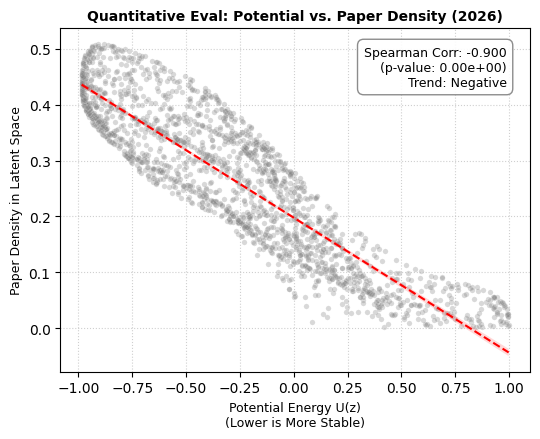

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, spearmanr
from sklearn.decomposition import PCA
import torch

def evaluate_quantitative_correlation(model, config, num_authors, device, year_idx=-1):
    """
    ポテンシャル場と論文密度の相関を定量評価
    
    理論的予測: ポテンシャルが低い領域ほど論文密度が高い（負の相関）
    これは物理系におけるアトラクター（安定点）の妥当性を示す
    
    Args:
        model: 学習済みモデル（UnifiedVGAE or ProposedPotentialODE）
        config: グラフデータを含む設定辞書
        num_authors: 著者ノードの数
        device: torch device
        year_idx: 評価対象の年インデックス（デフォルト: -1 = 最新年）
    """
    # スタイル設定（英語論文仕様）
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 10,
        'figure.figsize': (5, 4),
        'svg.fonttype': 'none',
    })
    
    print("\n[Evaluation] Verifying Attractor Validity (Potential vs Density)...")
    
    # 1. データ準備 (指定された年のグラフを取得)
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # ポテンシャルネットワークの取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: PotentialNet not found.")
        return

    # 2. 潜在変数とポテンシャル値の計算
    with torch.no_grad():
        # 次元の不整合があれば補正
        if hasattr(model, 'author_embeddings'):
            expected_dim = model.author_embeddings.embedding_dim 
        else:
            expected_dim = config['in_dim']
            
        current_dim = data.x.shape[1]
        x_input = data.x
        
        if current_dim != expected_dim:
            diff = expected_dim - current_dim
            if diff > 0:
                padding = torch.zeros((data.x.shape[0], diff), device=device)
                x_input = torch.cat([data.x, padding], dim=1)
            else:
                x_input = data.x[:, :expected_dim]
                
        # エンコード
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 3. 論文(Paper)ノードの抽出
    # num_authors 以降が Paper ノード
    paper_z = z_np[num_authors:]
    paper_potentials = potentials[num_authors:]
    
    # データが少なすぎる場合のガード
    if len(paper_z) < 10:
        print("Not enough paper nodes for density estimation.")
        return

    # 4. 密度推定 (KDE)
    # 高次元だと計算できないためPCAで2次元に落としてから密度を計算
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(paper_z)
    try:
        # 転置して (2, N) の形にする
        kde = gaussian_kde(z_2d.T)
        densities = kde(z_2d.T)
    except Exception as e:
        print(f"KDE Error: {e}")
        return

    # 5. 相関計算 (Spearman)
    # 理論通りなら「負の相関」になるはず（ポテンシャルが低いほど密度が高い）
    corr, p_value = spearmanr(paper_potentials, densities)
    
    # 6. プロット
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    
    # 描画負荷軽減のためのサンプリング
    if len(paper_potentials) > 2000:
        idx = np.random.choice(len(paper_potentials), 2000, replace=False)
        plot_x = paper_potentials[idx]
        plot_y = densities[idx]
        alpha_val = 0.3
    else:
        plot_x = paper_potentials
        plot_y = densities
        alpha_val = 0.5
        
    # 散布図
    ax.scatter(plot_x, plot_y, alpha=alpha_val, s=15, c='gray', 
               edgecolors='white', linewidth=0.3, label='Papers')
    
    # 回帰直線 (トレンドライン)
    sns.regplot(x=plot_x, y=plot_y, scatter=False, ax=ax, 
                color='red', line_kws={'linestyle':'--', 'linewidth':1.5}, label='Trend')
    
    # ラベル設定
    ax.set_title(f"Quantitative Eval: Potential vs. Paper Density ({target_year})", fontsize=10, fontweight='bold')
    ax.set_xlabel("Potential Energy U(z)\n(Lower is More Stable)", fontsize=9)
    ax.set_ylabel("Paper Density in Latent Space", fontsize=9)
    
    # 統計量テキスト表示
    correlation_text = "Negative" if corr < 0 else "Positive"
    stats_text = (f"Spearman Corr: {corr:.3f}\n"
                  f"(p-value: {p_value:.2e})\n"
                  f"Trend: {correlation_text}")
    
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()

    # 保存
    plt.savefig('./outputs/quantitative_eval_arxiv.svg', format='svg', bbox_inches='tight')
    plt.savefig('./outputs/quantitative_eval_arxiv.png', dpi=300)

    print("Evaluation plot saved to ./outputs/")
    print(f"Correlation: {corr:.4f} (Expected: Negative)")
    plt.show()

# ============================================================
# 実行ブロック
# ============================================================
if __name__ == "__main__":
    if 'model' in locals() and 'config' in locals():
        # 変数名の互換性チェック
        # config内のキーに応じて適切に num_authors を取得
        if 'num_authors' in config:
            n_authors = config['num_authors']
        elif 'num_corps' in config:
            n_authors = config['num_corps']  # 旧変数名との互換性
        else:
            n_authors = num_authors  # グローバル変数から取得
        
        evaluate_quantitative_correlation(
            model, 
            config, 
            num_authors=n_authors, 
            device=device
        )
    else:
        print("エラー: 学習済みモデルが見つかりません。")


[Evaluation] 技術戦略マップ（定義修正版）を作成中...
修正版プロットを保存しました: ./outputs/nature_strategy_landscape_jp_corrected.png


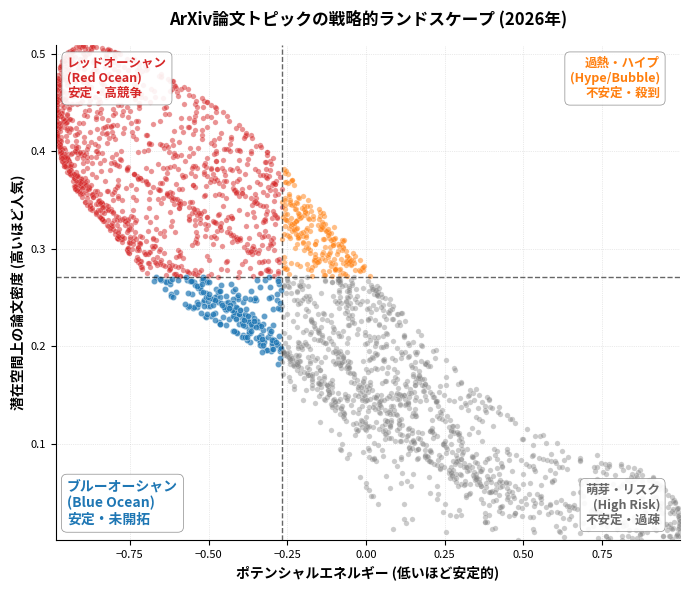

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, spearmanr
from sklearn.decomposition import PCA
import torch

# ============================================================
# 1. 日本語対応 Natureスタイル設定
# ============================================================
def set_nature_style_jp():
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': [
            'Hiragino Sans', 'Yu Gothic', 'Meiryo', 
            'Noto Sans CJK JP', 'Arial', 'Helvetica'
        ],
        'font.size': 10,
        'axes.labelsize': 9,
        'axes.titlesize': 11,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8,
        'figure.figsize': (6, 5),
        'axes.linewidth': 0.8,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'savefig.dpi': 300,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'svg.fonttype': 'none',  
    })

# ============================================================
# 2. 戦略的4象限分析 (定義修正版)
# ============================================================
def evaluate_strategic_quadrants_jp_corrected(model, config, num_authors, device, year_idx=-1):
    """
    ArXiv論文データにおける研究トピックの戦略的ランドスケープ分析
    
    4象限の解釈:
    - 左下 (ブルーオーシャン): 安定 & 低密度 → 最有望・狙い目の研究領域
    - 左上 (レッドオーシャン): 安定 & 高密度 → 既存・飽和・激戦区
    - 右上 (過熱・ハイプ): 不安定 & 高密度 → バブル・流行・一時的トレンド
    - 右下 (萌芽・リスク): 不安定 & 低密度 → 探索・黎明期・ハイリスク
    
    Args:
        model: 学習済みモデル
        config: グラフデータを含む設定辞書
        num_authors: 著者ノードの数
        device: torch device
        year_idx: 評価対象の年インデックス
    """
    set_nature_style_jp()
    print("\n[Evaluation] 技術戦略マップ（定義修正版）を作成中...")
    
    # --- 1. データ準備 ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # ネットワーク取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Potential Net not found.")
        return

    with torch.no_grad():
        # 次元数調整
        if hasattr(model, 'author_embeddings'):
            expected_dim = model.author_embeddings.embedding_dim 
        else:
            expected_dim = config['in_dim']
            
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            diff = expected_dim - x_input.shape[1]
            if diff > 0:
                padding = torch.zeros((x_input.shape[0], diff), device=device)
                x_input = torch.cat([x_input, padding], dim=1)
            else:
                x_input = x_input[:, :expected_dim]
                
        # エンコード
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 論文(Paper)データのみ抽出
    # num_authors 以降のインデックスが論文ノード
    paper_z = z_np[num_authors:]
    paper_potentials = potentials[num_authors:]
    
    # --- 2. 密度推定 (KDE) ---
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(paper_z)
    try:
        kde = gaussian_kde(z_2d.T)
        densities = kde(z_2d.T)
    except Exception as e:
        print(f"Error in KDE: {e}")
        return

    # サンプリング
    N_PLOT = 3000
    if len(paper_potentials) > N_PLOT:
        idx = np.random.choice(len(paper_potentials), N_PLOT, replace=False)
        plot_x = paper_potentials[idx]
        plot_y = densities[idx]
    else:
        plot_x = paper_potentials
        plot_y = densities

    # --- 3. 4象限の分類ロジック (修正版) ---
    x_thr = np.median(plot_x) # ポテンシャル中央値
    y_thr = np.median(plot_y) # 密度中央値
    
    # 【左下】ブルーオーシャン (安定 & 低密度) -> 最有望・狙い目
    mask_blue = (plot_x <= x_thr) & (plot_y <= y_thr)
    
    # 【左上】レッドオーシャン (安定 & 高密度) -> 既存・飽和・激戦区
    mask_red = (plot_x <= x_thr) & (plot_y > y_thr)
    
    # 【右上】過熱・ハイプ (不安定 & 高密度) -> バブル・流行・一時的
    mask_hype = (plot_x > x_thr) & (plot_y > y_thr)
    
    # 【右下】萌芽・リスク (不安定 & 低密度) -> 探索・黎明期
    mask_risk = (plot_x > x_thr) & (plot_y <= y_thr)

    # --- 4. プロット ---
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # 左上: レッドオーシャン (赤)
    ax.scatter(plot_x[mask_red], plot_y[mask_red], c='#d62728', s=15, alpha=0.5, 
               label='レッドオーシャン (飽和)', edgecolors='white', linewidth=0.2)
    
    # 左下: ブルーオーシャン (青 - 最も目立たせる)
    ax.scatter(plot_x[mask_blue], plot_y[mask_blue], c='#1f77b4', s=20, alpha=0.7, 
               label='ブルーオーシャン (有望)', edgecolors='white', linewidth=0.3)
    
    # 右上: 過熱・ハイプ (オレンジ/黄色)
    ax.scatter(plot_x[mask_hype], plot_y[mask_hype], c='#ff7f0e', s=15, alpha=0.5, 
               label='過熱・ハイプ (バブル)', edgecolors='white', linewidth=0.2)
    
    # 右下: 萌芽・リスク (灰)
    ax.scatter(plot_x[mask_risk], plot_y[mask_risk], c='#7f7f7f', s=15, alpha=0.4, 
               label='萌芽・リスク (探索)', edgecolors='white', linewidth=0.2)

    # しきい値線
    ax.axvline(x=x_thr, color='black', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.axhline(y=y_thr, color='black', linestyle='--', linewidth=1.0, alpha=0.6)

    # ラベル配置 (ボックス付き)
    box_props = dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='gray', linewidth=0.5)
    
    x_min, x_max = plot_x.min(), plot_x.max()
    y_min, y_max = plot_y.min(), plot_y.max()
    
    # 左上
    ax.text(x_min + (x_thr - x_min)*0.05, y_max - (y_max - y_thr)*0.05, 
            "レッドオーシャン\n(Red Ocean)\n安定・高競争", 
            fontsize=9, color='#d62728', fontweight='bold', bbox=box_props, ha='left', va='top')
            
    # 左下 (ここがターゲット)
    ax.text(x_min + (x_thr - x_min)*0.05, y_min + (y_thr - y_min)*0.05, 
            "ブルーオーシャン\n(Blue Ocean)\n安定・未開拓", 
            fontsize=10, color='#1f77b4', fontweight='bold', bbox=box_props, ha='left', va='bottom')
            
    # 右上
    ax.text(x_max - (x_max - x_thr)*0.05, y_max - (y_max - y_thr)*0.05, 
            "過熱・ハイプ\n(Hype/Bubble)\n不安定・殺到", 
            fontsize=9, color='#ff7f0e', fontweight='bold', bbox=box_props, ha='right', va='top')
            
    # 右下
    ax.text(x_max - (x_max - x_thr)*0.05, y_min + (y_thr - y_min)*0.05, 
            "萌芽・リスク\n(High Risk)\n不安定・過疎", 
            fontsize=9, color='#666666', fontweight='bold', bbox=box_props, ha='right', va='bottom')

    # 軸ラベル
    ax.set_xlabel("ポテンシャルエネルギー (低いほど安定的)", fontsize=10, fontweight='bold')
    ax.set_ylabel("潜在空間上の論文密度 (高いほど人気)", fontsize=10, fontweight='bold')
    ax.set_title(f"ArXiv論文トピックの戦略的ランドスケープ ({target_year}年)", fontsize=12, fontweight='bold', pad=15)
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle=':', alpha=0.5)
    
    plt.tight_layout()

    # 保存
    plt.savefig('./outputs/nature_strategy_landscape_jp_corrected.svg', format='svg', bbox_inches='tight')
    plt.savefig('./outputs/nature_strategy_landscape_jp_corrected.png', dpi=300)
    
    print("修正版プロットを保存しました: ./outputs/nature_strategy_landscape_jp_corrected.png")
    plt.show()

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    if 'config' in locals() and 'model' in locals():
        # 変数名の互換性チェック
        if 'num_authors' in config:
            n_authors = config['num_authors']
        elif 'num_corps' in config:
            n_authors = config['num_corps']  # 旧変数名との互換性
        else:
            n_authors = num_authors  # グローバル変数から取得
        
        evaluate_strategic_quadrants_jp_corrected(
            model, config, 
            num_authors=n_authors, 
            device=device
        )
    else:
        print("Model or config not loaded.")


[Evaluation] 技術戦略マップ（CSV出力付き）を作成中...
✓ プロット保存: ./outputs/nature_strategy_landscape_jp_corrected.png


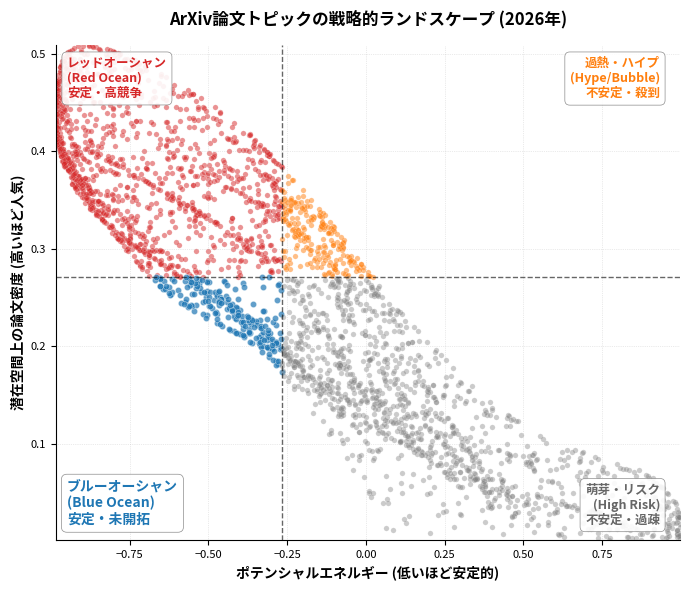


[Analysis] 各象限の具体的な論文を抽出中...
  - ブルーオーシャン象限を抽出中...
    → 88件抽出
  - レッドオーシャン象限を抽出中...
    → 405件抽出
  - 過熱・ハイプ象限を抽出中...
    → 59件抽出
  - 萌芽・リスク象限を抽出中...
    → 490件抽出

✓ 全象限の論文詳細を保存: ./outputs/all_quadrants_papers_detailed.csv
  総論文数: 1042件
  - ブルーオーシャン: 88件
  - レッドオーシャン: 405件
  - 過熱・ハイプ: 59件
  - 萌芽・リスク: 490件

✓ 象限統計サマリー保存: ./outputs/quadrants_summary_statistics.csv

【象限統計】
         象限名  論文数 割合(%) ポテンシャル平均 ポテンシャル標準偏差       密度平均     密度標準偏差
ブルーオーシャン（有望）  601   7.3  -0.4225     0.1022 2.3467e-01 2.2190e-02
レッドオーシャン（飽和） 3521  42.7  -0.7144     0.2188 3.8528e-01 6.0596e-02
 過熱・ハイプ（バブル）  601   7.3  -0.1623     0.0702 3.1292e-01 2.5971e-02
  萌芽・リスク（探索） 3521  42.7   0.2153     0.3358 1.2784e-01 7.2644e-02

【実行完了】以下のファイルが生成されました:
  1. ./outputs/nature_strategy_landscape_jp_corrected.png  (可視化)
  2. ./outputs/all_quadrants_papers_detailed.csv  (全論文詳細)
  3. ./outputs/quadrants_summary_statistics.csv  (統計サマリー)


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, spearmanr
from sklearn.decomposition import PCA
import torch
import pandas as pd

# ============================================================
# 1. 日本語対応 Natureスタイル設定
# ============================================================
def set_nature_style_jp():
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': [
            'Hiragino Sans', 'Yu Gothic', 'Meiryo', 
            'Noto Sans CJK JP', 'Arial', 'Helvetica'
        ],
        'font.size': 10,
        'axes.labelsize': 9,
        'axes.titlesize': 11,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8,
        'figure.figsize': (6, 5),
        'axes.linewidth': 0.8,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'savefig.dpi': 300,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'svg.fonttype': 'none',  
    })

# ============================================================
# 2. 戦略的4象限分析（CSV出力付き完全版）
# ============================================================
def evaluate_strategic_quadrants_jp_corrected(model, config, df, num_authors, device, year_idx=-1):
    """
    ArXiv論文データにおける研究トピックの戦略的ランドスケープ分析
    全象限の論文をCSV形式で詳細に保存
    
    Args:
        model: 学習済みモデル
        config: グラフデータを含む設定辞書
        df: 元のDataFrame（ArXivデータ）
        num_authors: 著者ノードの数
        device: torch device
        year_idx: 評価対象の年インデックス
    
    Returns:
        df_all_quadrants: 全論文の詳細DataFrame
        df_summary: 象限統計サマリーDataFrame
    """
    set_nature_style_jp()
    print("\n[Evaluation] 技術戦略マップ（CSV出力付き）を作成中...")
    
    # --- 1. データ準備 ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # ポテンシャルネットワーク取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Potential Net not found.")
        return None, None

    with torch.no_grad():
        # 次元数調整
        if hasattr(model, 'author_embeddings'):
            expected_dim = model.author_embeddings.embedding_dim 
        else:
            expected_dim = config['in_dim']
            
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            diff = expected_dim - x_input.shape[1]
            if diff > 0:
                padding = torch.zeros((x_input.shape[0], diff), device=device)
                x_input = torch.cat([x_input, padding], dim=1)
            else:
                x_input = x_input[:, :expected_dim]
                
        # エンコード
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 論文データのみ抽出
    paper_z = z_np[num_authors:]
    paper_potentials = potentials[num_authors:]
    
    # --- 2. 密度推定 (KDE) ---
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(paper_z)
    try:
        kde = gaussian_kde(z_2d.T)
        densities = kde(z_2d.T)
    except Exception as e:
        print(f"Error in KDE: {e}")
        return None, None

    # --- 3. 4象限の分類 ---
    pot_threshold = np.median(paper_potentials)
    dens_threshold = np.median(densities)
    
    # 各象限のマスク
    mask_blue = (paper_potentials <= pot_threshold) & (densities <= dens_threshold)
    mask_red = (paper_potentials <= pot_threshold) & (densities > dens_threshold)
    mask_hype = (paper_potentials > pot_threshold) & (densities > dens_threshold)
    mask_risk = (paper_potentials > pot_threshold) & (densities <= dens_threshold)

    # --- 4. プロット作成 ---
    # サンプリング（表示用）
    N_PLOT = 3000
    if len(paper_potentials) > N_PLOT:
        plot_idx = np.random.choice(len(paper_potentials), N_PLOT, replace=False)
        plot_x = paper_potentials[plot_idx]
        plot_y = densities[plot_idx]
        plot_mask_blue = mask_blue[plot_idx]
        plot_mask_red = mask_red[plot_idx]
        plot_mask_hype = mask_hype[plot_idx]
        plot_mask_risk = mask_risk[plot_idx]
    else:
        plot_x = paper_potentials
        plot_y = densities
        plot_mask_blue = mask_blue
        plot_mask_red = mask_red
        plot_mask_hype = mask_hype
        plot_mask_risk = mask_risk

    fig, ax = plt.subplots(figsize=(7, 6))
    
    ax.scatter(plot_x[plot_mask_red], plot_y[plot_mask_red], c='#d62728', s=15, alpha=0.5, 
               label='レッドオーシャン (飽和)', edgecolors='white', linewidth=0.2)
    ax.scatter(plot_x[plot_mask_blue], plot_y[plot_mask_blue], c='#1f77b4', s=20, alpha=0.7, 
               label='ブルーオーシャン (有望)', edgecolors='white', linewidth=0.3)
    ax.scatter(plot_x[plot_mask_hype], plot_y[plot_mask_hype], c='#ff7f0e', s=15, alpha=0.5, 
               label='過熱・ハイプ (バブル)', edgecolors='white', linewidth=0.2)
    ax.scatter(plot_x[plot_mask_risk], plot_y[plot_mask_risk], c='#7f7f7f', s=15, alpha=0.4, 
               label='萌芽・リスク (探索)', edgecolors='white', linewidth=0.2)

    ax.axvline(x=pot_threshold, color='black', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.axhline(y=dens_threshold, color='black', linestyle='--', linewidth=1.0, alpha=0.6)

    box_props = dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='gray', linewidth=0.5)
    
    x_min, x_max = plot_x.min(), plot_x.max()
    y_min, y_max = plot_y.min(), plot_y.max()
    
    ax.text(x_min + (pot_threshold - x_min)*0.05, y_max - (y_max - dens_threshold)*0.05, 
            "レッドオーシャン\n(Red Ocean)\n安定・高競争", 
            fontsize=9, color='#d62728', fontweight='bold', bbox=box_props, ha='left', va='top')
    ax.text(x_min + (pot_threshold - x_min)*0.05, y_min + (dens_threshold - y_min)*0.05, 
            "ブルーオーシャン\n(Blue Ocean)\n安定・未開拓", 
            fontsize=10, color='#1f77b4', fontweight='bold', bbox=box_props, ha='left', va='bottom')
    ax.text(x_max - (x_max - pot_threshold)*0.05, y_max - (y_max - dens_threshold)*0.05, 
            "過熱・ハイプ\n(Hype/Bubble)\n不安定・殺到", 
            fontsize=9, color='#ff7f0e', fontweight='bold', bbox=box_props, ha='right', va='top')
    ax.text(x_max - (x_max - pot_threshold)*0.05, y_min + (dens_threshold - y_min)*0.05, 
            "萌芽・リスク\n(High Risk)\n不安定・過疎", 
            fontsize=9, color='#666666', fontweight='bold', bbox=box_props, ha='right', va='bottom')

    ax.set_xlabel("ポテンシャルエネルギー (低いほど安定的)", fontsize=10, fontweight='bold')
    ax.set_ylabel("潜在空間上の論文密度 (高いほど人気)", fontsize=10, fontweight='bold')
    ax.set_title(f"ArXiv論文トピックの戦略的ランドスケープ ({target_year}年)", fontsize=12, fontweight='bold', pad=15)
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle=':', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig('./outputs/nature_strategy_landscape_jp_corrected.svg', format='svg', bbox_inches='tight')
    plt.savefig('./outputs/nature_strategy_landscape_jp_corrected.png', dpi=300)
    print("✓ プロット保存: ./outputs/nature_strategy_landscape_jp_corrected.png")
    plt.show()
    
    # --- 5. 全象限の論文詳細をCSV形式で抽出・保存 ---
    print("\n[Analysis] 各象限の具体的な論文を抽出中...")
    
    # 論文URLリスト取得
    if 'papers' in config:
        paper_urls = config['papers']
    else:
        year_df = df[df['year'] == target_year] if 'year' in df.columns else df
        paper_urls = year_df['url'].unique().tolist()
    
    def extract_quadrant_papers(mask, quadrant_name, sort_by='potential', ascending=True):
        """指定象限の論文を抽出"""
        indices = np.where(mask)[0]
        if len(indices) == 0:
            return []
        
        # ソート
        scores = paper_potentials[indices] if sort_by == 'potential' else densities[indices]
        sorted_order = np.argsort(scores) if ascending else np.argsort(scores)[::-1]
        sorted_indices = indices[sorted_order]
        
        results = []
        for rank, idx in enumerate(sorted_indices, 1):
            if idx < len(paper_urls):
                paper_url = paper_urls[idx]
                row = df[df['url'] == paper_url]
                
                if not row.empty:
                    info = row.iloc[0]
                    
                    # 情報取得
                    title = info.get('title', 'No Title')
                    if pd.isna(title) or title == "": title = "タイトル情報なし"
                    
                    authors = info.get('authors', '')
                    if isinstance(authors, str):
                        author_list = [a.strip() for a in authors.split(',')]
                        authors_display = ', '.join(author_list[:3]) + (' et al.' if len(author_list) > 3 else '')
                    else:
                        authors_display = str(authors) if not pd.isna(authors) else "著者情報なし"
                    
                    year = int(info.get('year', target_year)) if not pd.isna(info.get('year')) else target_year
                    topic = info.get('topic', 'トピック情報なし')
                    if pd.isna(topic) or topic == "": topic = "トピック情報なし"
                    
                    description = info.get('description', '')
                    if pd.isna(description) or description == "":
                        description = "要約なし"
                    else:
                        description = str(description)[:200] + ("..." if len(str(description)) > 200 else "")
                    
                    results.append({
                        "象限": quadrant_name,
                        "象限内順位": rank,
                        "論文URL": paper_url,
                        "タイトル": title,
                        "著者": authors_display,
                        "年": year,
                        "トピック": topic,
                        "ポテンシャル": f"{paper_potentials[idx]:.6f}",
                        "密度": f"{densities[idx]:.6e}",
                        "安定性": "高" if paper_potentials[idx] <= pot_threshold else "低",
                        "競争度": "高" if densities[idx] > dens_threshold else "低",
                        "要約": description
                    })
        
        return results
    
    # 各象限から抽出
    all_results = []
    
    print("  - ブルーオーシャン象限を抽出中...")
    blue_papers = extract_quadrant_papers(mask_blue, "ブルーオーシャン（有望）", sort_by='potential', ascending=True)
    all_results.extend(blue_papers)
    print(f"    → {len(blue_papers)}件抽出")
    
    print("  - レッドオーシャン象限を抽出中...")
    red_papers = extract_quadrant_papers(mask_red, "レッドオーシャン（飽和）", sort_by='density', ascending=False)
    all_results.extend(red_papers)
    print(f"    → {len(red_papers)}件抽出")
    
    print("  - 過熱・ハイプ象限を抽出中...")
    hype_papers = extract_quadrant_papers(mask_hype, "過熱・ハイプ（バブル）", sort_by='density', ascending=False)
    all_results.extend(hype_papers)
    print(f"    → {len(hype_papers)}件抽出")
    
    print("  - 萌芽・リスク象限を抽出中...")
    risk_papers = extract_quadrant_papers(mask_risk, "萌芽・リスク（探索）", sort_by='potential', ascending=False)
    all_results.extend(risk_papers)
    print(f"    → {len(risk_papers)}件抽出")
    
    # DataFrameに変換・保存
    df_all_quadrants = pd.DataFrame(all_results)
    csv_path = './outputs/all_quadrants_papers_detailed.csv'
    df_all_quadrants.to_csv(csv_path, index=False, encoding='utf-8-sig')
    
    print(f"\n✓ 全象限の論文詳細を保存: {csv_path}")
    print(f"  総論文数: {len(df_all_quadrants)}件")
    print(f"  - ブルーオーシャン: {len(blue_papers)}件")
    print(f"  - レッドオーシャン: {len(red_papers)}件")
    print(f"  - 過熱・ハイプ: {len(hype_papers)}件")
    print(f"  - 萌芽・リスク: {len(risk_papers)}件")
    
    # 統計サマリー作成
    summary_stats = []
    for quadrant_name, mask in [
        ("ブルーオーシャン（有望）", mask_blue),
        ("レッドオーシャン（飽和）", mask_red),
        ("過熱・ハイプ（バブル）", mask_hype),
        ("萌芽・リスク（探索）", mask_risk)
    ]:
        count = mask.sum()
        if count > 0:
            summary_stats.append({
                "象限名": quadrant_name,
                "論文数": count,
                "割合(%)": f"{(count / len(paper_potentials) * 100):.1f}",
                "ポテンシャル平均": f"{paper_potentials[mask].mean():.4f}",
                "ポテンシャル標準偏差": f"{paper_potentials[mask].std():.4f}",
                "密度平均": f"{densities[mask].mean():.4e}",
                "密度標準偏差": f"{densities[mask].std():.4e}"
            })
    
    df_summary = pd.DataFrame(summary_stats)
    summary_path = './outputs/quadrants_summary_statistics.csv'
    df_summary.to_csv(summary_path, index=False, encoding='utf-8-sig')
    
    print(f"\n✓ 象限統計サマリー保存: {summary_path}")
    print("\n【象限統計】")
    print(df_summary.to_string(index=False))
    
    return df_all_quadrants, df_summary

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    if 'config' in locals() and 'model' in locals() and 'df' in locals():
        # 変数名の互換性チェック
        if 'num_authors' in config:
            n_authors = config['num_authors']
        elif 'num_corps' in config:
            n_authors = config['num_corps']
        else:
            n_authors = num_authors
        
        df_all_papers, df_stats = evaluate_strategic_quadrants_jp_corrected(
            model, config, df,
            num_authors=n_authors, 
            device=device
        )
        
        print("\n" + "="*100)
        print("【実行完了】以下のファイルが生成されました:")
        print("  1. ./outputs/nature_strategy_landscape_jp_corrected.png  (可視化)")
        print("  2. ./outputs/all_quadrants_papers_detailed.csv  (全論文詳細)")
        print("  3. ./outputs/quadrants_summary_statistics.csv  (統計サマリー)")
        print("="*100)
    else:
        print("エラー: model, config, df が必要です。")
        print("前段のコードでデータ読み込みと学習を実行してください。")

In [10]:
df_all_papers 

,象限,象限内順位,論文URL,タイトル,著者,年,トピック,ポテンシャル,密度,安定性,競争度,要約
0,ブルーオーシャン（有望）,1,http://arxiv.org/abs/2601.11035v1,Your One-Stop Solution for AI-Generated Video ...,"Long Ma, Zihao Xue, Yan Wang et al.",2026,cs.CV,-0.680976,2.685705e-01,高,低,Recent advances in generative modeling can cre...
1,ブルーオーシャン（有望）,9,http://arxiv.org/abs/2601.04567v1,All Changes May Have Invariant Principles: Imp...,"Ziyou Jiang, Mingyang Li, Junjie Wang et al.",2026,cs.CV,-0.653104,2.685872e-01,高,低,Harmful memes are ever-shifting in the Interne...
2,ブルーオーシャン（有望）,15,http://arxiv.org/abs/2601.04537v1,Not All Steps are Informative: On the Linearit...,"Tianle Wang, Zhongyuan Wu, Shenghao Jin et al.",2026,cs.LG,-0.639721,2.670150e-01,高,低,Reinforcement learning with verifiable rewards...
3,ブルーオーシャン（有望）,27,http://arxiv.org/abs/2601.05604v1,Learning Geometric Invariance for Gait Recogni...,"Zengbin Wang, Junjie Li, Saihui Hou et al.",2026,cs.CV,-0.617778,2.514457e-01,高,低,The goal of gait recognition is to extract ide...
4,ブルーオーシャン（有望）,33,http://arxiv.org/abs/2601.11883v1,Approximation Algorithm for Constrained $k$-Ce...,"Chaoqi Jia, Longkun Guo, Kewen Liao et al.",2026,cs.LG,-0.604759,2.553030e-01,高,低,Clustering is a long-standing research problem...
...,...,...,...,...,...,...,...,...,...,...,...,...
1037,萌芽・リスク（探索）,3511,http://arxiv.org/abs/2601.04548v1,Identifying Good and Bad Neurons for Task-Leve...,"Wenjie Li, Guansong Pang, Hezhe Qiao et al.",2026,cs.CL,-0.263454,2.350007e-01,低,低,Large Language Models have demonstrated remark...
1038,萌芽・リスク（探索）,3514,http://arxiv.org/abs/2601.06413v1,GlobalPaint: Spatiotemporal Coherent Video Out...,"Yueming Pan, Ruoyu Feng, Jianmin Bao et al.",2026,cs.CV,-0.263690,1.714291e-01,低,低,Video outpainting extends a video beyond its o...
1039,萌芽・リスク（探索）,3518,http://arxiv.org/abs/2601.06404v1,One-Shot Hierarchical Federated Clustering,"Shenghong Cai, Zihua Yang, Yang Lu et al.",2026,cs.LG,-0.265561,2.411600e-01,低,低,Driven by the growth of Web-scale decentralize...
1040,萌芽・リスク（探索）,3519,http://arxiv.org/abs/2601.07180v1,Structured Reasoning for Large Language Models,"Jinyi Han, Zixiang Di, Zishang Jiang et al.",2026,cs.CL,-0.265610,1.833472e-01,低,低,Large language models (LLMs) achieve strong pe...


In [16]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def set_japanese_font():
    # 一般的な日本語フォントのリスト
    fonts = [
        'Hiragino Sans', 'Yu Gothic', 'Meiryo', 'Takao', 'IPAexGothic', 'IPAGothic', 'VL Gothic', 'Noto Sans CJK JP'
    ]
    
    found = False
    for font in fonts:
        try:
            # フォントがシステムにあるかチェック
            fm.findfont(font, fallback_to_default=False)
            plt.rcParams['font.family'] = font
            print(f"日本語フォントを設定しました: {font}")
            found = True
            break
        except:
            continue
            
    if not found:
        print("警告: 適切な日本語フォントが見つかりませんでした。英語表示に切り替えるか、japanize-matplotlibをインストールしてください。")

# 設定を実行
set_japanese_font()

日本語フォントを設定しました: IPAexGothic


[Analysis] Aggregating topic distribution (English Mode)...

 TOPICS BY QUADRANT (Top 5)

### Blue Ocean (Niche/Stable)
 Rank Topic  Count Share
    1 cs.CV     35 39.8%
    2 cs.CL     29 33.0%
    3 cs.LG     17 19.3%
    4 cs.AI      4  4.5%
    5 cs.SD      2  2.3%
------------------------------------------------------------

### Red Ocean (Mainstream)
 Rank Topic  Count Share
    1 cs.CV    161 39.8%
    2 cs.CL    132 32.6%
    3 cs.LG     61 15.1%
    4 cs.AI     21  5.2%
    5 cs.RO      7  1.7%
------------------------------------------------------------

### Hype (Overheated)
 Rank Topic  Count Share
    1 cs.CV     26 44.1%
    2 cs.CL     15 25.4%
    3 cs.LG      8 13.6%
    4 cs.AI      6 10.2%
    5 cs.AR      1  1.7%
------------------------------------------------------------

### High Risk (Emerging)
 Rank Topic  Count Share
    1 cs.CV    206 42.0%
    2 cs.CL    121 24.7%
    3 cs.LG    103 21.0%
    4 cs.AI     19  3.9%
    5 cs.RO     14  2.9%
--------------------

<Figure size 1400x1000 with 0 Axes>

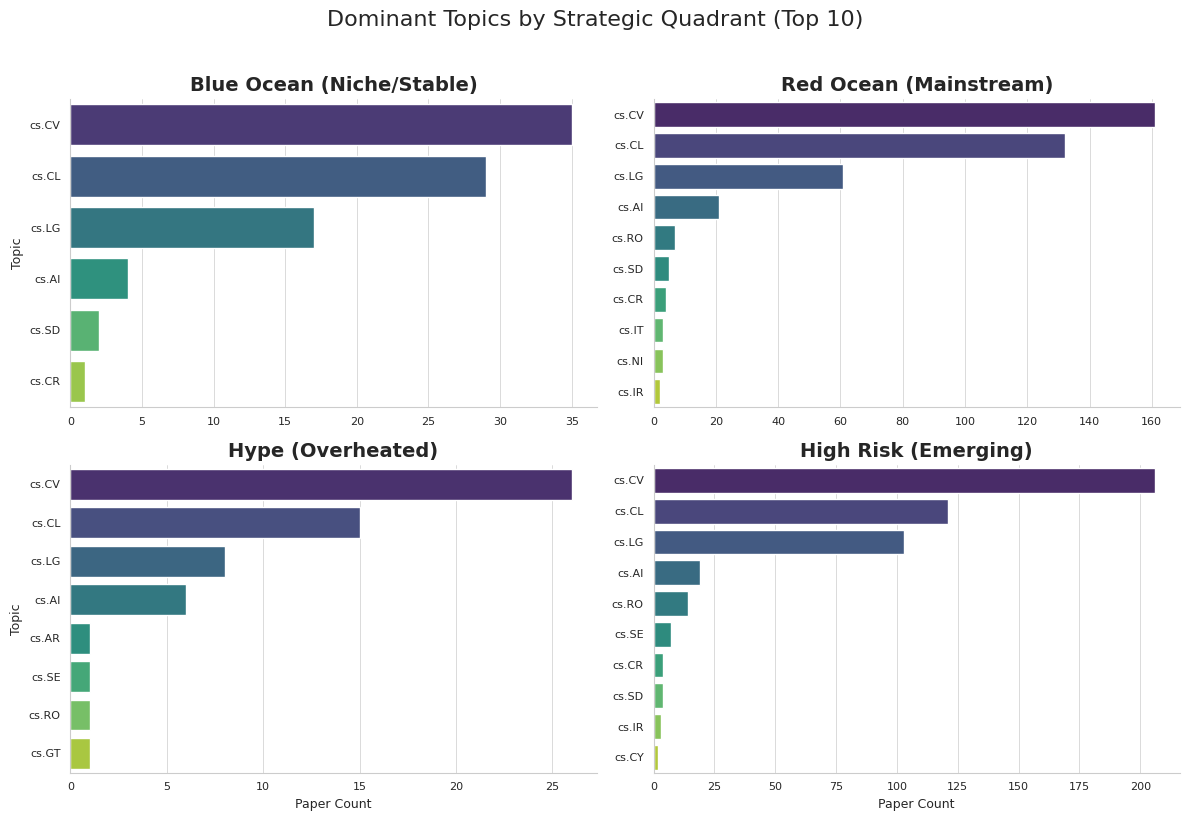

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_topic_distribution_english(df_all_papers, top_k=10):
    """
    Analyzes topic distribution by quadrant and visualizes in English.
    Converts Japanese quadrant names to English automatically.
    """
    print("[Analysis] Aggregating topic distribution (English Mode)...")

    # --- 1. Translate Quadrant Names to English ---
    # Mapping dictionary from the previous Japanese labels
    jp_to_en = {
        "ブルーオーシャン（有望）": "Blue Ocean (Niche/Stable)",
        "レッドオーシャン（飽和）": "Red Ocean (Mainstream)",
        "過熱・ハイプ（バブル）": "Hype (Overheated)",
        "萌芽・リスク（探索）": "High Risk (Emerging)",
        # In case it's already English or simple labels
        "Blue Ocean": "Blue Ocean (Niche/Stable)",
        "Red Ocean": "Red Ocean (Mainstream)",
        "Trend": "Hype (Overheated)",
        "Frontier": "High Risk (Emerging)"
    }
    
    # Create a copy to avoid modifying the original DF
    df_clean = df_all_papers.copy()
    
    # Map to English (if key exists, otherwise keep original)
    df_clean['Quadrant_En'] = df_clean['象限'].map(lambda x: jp_to_en.get(x, x))

    # --- 2. Data Preprocessing (Explode Topics) ---
    # Split "cs.CV, cs.LG" into separate rows
    df_exploded = df_clean.assign(topic_split=df_clean['トピック'].str.split(',')).explode('topic_split')
    df_exploded['topic_clean'] = df_exploded['topic_split'].str.strip()
    
    # Remove invalid topics
    exclude_list = ["トピック情報なし", "Unknown", "", "nan", "No Topic"]
    df_processed = df_exploded[~df_exploded['topic_clean'].isin(exclude_list)]

    # --- 3. Aggregate by Quadrant ---
    results = []
    unique_quadrants = df_processed['Quadrant_En'].unique()

    for quad in unique_quadrants:
        df_quad = df_processed[df_processed['Quadrant_En'] == quad]
        total_count = len(df_quad)
        
        # Count topics
        topic_counts = df_quad['topic_clean'].value_counts().head(top_k)
        
        for rank, (topic, count) in enumerate(topic_counts.items(), 1):
            results.append({
                "Quadrant": quad,
                "Rank": rank,
                "Topic": topic,
                "Count": count,
                "Share": count / total_count
            })

    df_ranking = pd.DataFrame(results)

    # Define Sort Order for Visualization
    # 1. Blue, 2. Red, 3. Hype, 4. Risk
    sort_priority = {
        "Blue Ocean (Niche/Stable)": 1,
        "Red Ocean (Mainstream)": 2,
        "Hype (Overheated)": 3,
        "High Risk (Emerging)": 4
    }
    df_ranking['sort_key'] = df_ranking['Quadrant'].map(sort_priority).fillna(99)
    df_ranking = df_ranking.sort_values(['sort_key', 'Rank'])

    # --- 4. Display Text Report ---
    print("\n" + "="*80)
    print(" TOPICS BY QUADRANT (Top 5)")
    print("="*80)
    
    for quad in df_ranking['Quadrant'].unique():
        print(f"\n### {quad}")
        subset = df_ranking[df_ranking['Quadrant'] == quad]
        # Format share as percentage
        subset_display = subset.copy()
        subset_display['Share'] = subset_display['Share'].map(lambda x: f"{x*100:.1f}%")
        print(subset_display[['Rank', 'Topic', 'Count', 'Share']].head(5).to_string(index=False))
        print("-" * 60)

    # --- 5. Visualization (Seaborn) ---
    # Reset font to default (sans-serif) to ensure English renders correctly
    plt.rcParams.update({'font.family': 'sans-serif'})
    plt.figure(figsize=(14, 10))
    sns.set_style("whitegrid")

    # Create FacetGrid
    g = sns.FacetGrid(
        df_ranking, 
        col="Quadrant", 
        col_wrap=2, 
        height=4, 
        aspect=1.5, 
        sharex=False, 
        sharey=False
    )
    
    # Map Barplot
    g.map(sns.barplot, "Count", "Topic", order=None, palette="viridis")
    
    # Titles and Labels
    g.fig.suptitle(f"Dominant Topics by Strategic Quadrant (Top {top_k})", fontsize=16, y=1.02)
    g.set_titles("{col_name}", size=14, fontweight='bold')
    g.set_axis_labels("Paper Count", "Topic")
    
    plt.tight_layout()
    plt.show()

    return df_ranking

# --- Execution ---
if 'df_all_papers' in locals():
    df_topic_ranking_en = analyze_topic_distribution_english(df_all_papers, top_k=10)
else:
    print("Error: 'df_all_papers' not found. Please run the previous analysis step first.")

# アブステレーション分析


In [ ]:
# ============================================================
# 4. 損失関数 (修正版: **kwargsを追加)
# ============================================================
def compute_loss_standardized(model, data_t, data_t1, num_authors, z_history_for_prediction,
                              historical_edges, beta=0.01, pos_weight=5.0,
                              latent_pred_weight=1.0, future_link_weight=10.0,
                              potential_weight=0.1, repulsion_weight=5.0,
                              **kwargs): # <--- 【修正】他のパラメータ(total_nなど)が来ても無視するようにする
    
    device = data_t.x.device
    node_indices = torch.arange(model.num_nodes, device=device)
    paper_mask = (node_indices >= num_authors) & data_t.active_mask
    
    # 1. エンコード
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    
    # 2. 再構成損失
    pos_edge_index = data_t.edge_index
    active_authors = torch.unique(pos_edge_index[0][pos_edge_index[0] < num_authors])
    active_papers = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_authors])
    pos_set = set(tuple(p.tolist()) for p in pos_edge_index.t())
    
    neg_edge_index = sample_hard_negatives_v2(model, z_t, active_authors, active_papers, 
                                                pos_set, historical_edges, num_samples=500)
    
    recon_loss = torch.tensor(0.0, device=device)
    if neg_edge_index is not None:
        pos_pred = model.decode(z_t, pos_edge_index)
        neg_pred = model.decode(z_t, neg_edge_index)
        node_degrees = torch.zeros(model.num_nodes, device=device)
        node_degrees.index_add_(0, data_t.edge_index.view(-1), torch.ones(data_t.edge_index.numel(), device=device))
        edge_rarity = 1.0 / torch.log(node_degrees[pos_edge_index[0]] * node_degrees[pos_edge_index[1]] + 1e-15)
        
        recon_loss = -(torch.log(pos_pred + 1e-15) * edge_rarity).mean() * pos_weight \
                     - torch.log(1 - neg_pred + 1e-15).mean()

    # KL損失
    kl_loss = -0.5 * torch.mean(1 + logvar_t[data_t.active_mask] - mu_t[data_t.active_mask].pow(2) - logvar_t[data_t.active_mask].exp())

    # 3. ポテンシャル学習
    potential_loss = torch.tensor(0.0, device=device)
    has_potential = hasattr(model.temporal_predictor, 'potential_net')
    
    if potential_weight > 0 and has_potential:
        phi = model.temporal_predictor.potential_net(mu_t)
        src, dst = data_t.edge_index
        pos_pot = phi[src] + phi[dst]
        perm = torch.randperm(dst.size(0))
        neg_dst = dst[perm]
        neg_pot = phi[src] + phi[neg_dst]
        loss_contrastive = torch.relu(pos_pot - neg_pot + 0.1).mean()
        loss_reg = 0.01 * (phi ** 2).mean()
        potential_loss = loss_contrastive + loss_reg

    # 4. 未来予測 (ODE)
    z_t1_pred = model.predict_future(z_history_for_prediction)
    with torch.no_grad():
        _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
    latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

    # 5. 未来リンク予測
    future_link_loss = torch.tensor(0.0, device=device)
    pos_edge_index_t1 = data_t1.edge_index
    if pos_edge_index_t1.size(1) > 0:
        active_a_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_authors])
        active_p_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_authors])
        pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
        
        neg_t1 = sample_hard_negatives_v2(model, z_t1_pred, active_a_t1, active_p_t1, pos_set_t1, historical_edges, num_samples=300)
        if neg_t1 is not None:
            future_link_loss = -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() - \
                               torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()

    # 6. 反発力損失
    repulsion_loss = torch.tensor(0.0, device=device)
    z_papers = z_t[paper_mask]
    if z_papers.size(0) > 100:
        idx_sub = torch.randperm(z_papers.size(0))[:200]
        z_sub = z_papers[idx_sub]
        dist_matrix = torch.cdist(z_sub, z_sub)
        eye_mask = ~torch.eye(dist_matrix.size(0), dtype=torch.bool, device=device)
        repulsion_loss = torch.relu(0.5 - dist_matrix[eye_mask]).mean()

    total_loss = (recon_loss + beta * kl_loss + latent_pred_weight * latent_pred_loss + 
                  future_link_weight * future_link_loss + potential_weight * potential_loss + 
                  repulsion_weight * repulsion_loss)
    
    return total_loss, {
        'total': total_loss.item(), 'potential': potential_loss.item(), 
        'future': future_link_loss.item(), 'repulsion': repulsion_loss.item()
    }

# ============================================================
# 6. 学習ループ (修正版: model.num_nodesを使用)
# ============================================================
def train_model_improved(model, global_graph_dict, num_authors, historical_edges, 
                         loss_config, num_epochs=20):
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    years = sorted(global_graph_dict.keys())
    train_years = years[:int(len(years) * 0.75)]
    val_years = years[int(len(years) * 0.75):]
    
    history = {'train_loss': [], 'val_mrr': [], 'val_auc': [], 'dispersion': [], 'consistency': []}
    
    all_true_edges = set()
    for y in years:
        all_true_edges.update([tuple(e) for e in global_graph_dict[y].edge_index.t().tolist()])
    
    best_mrr = 0.0
    best_auc = 0.0
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        # --- Train ---
        for i in range(len(train_years) - 1):
            year_t = train_years[i]
            year_t1 = train_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            z_history = []
            for j in range(max(0, i - 2), i + 1):
                with torch.no_grad():
                    d = global_graph_dict[train_years[j]].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_history.append(z)
            
            optimizer.zero_grad()
            # ここで余分な引数(total_nなど)があっても **kwargs で吸収されます
            loss, _ = compute_loss_standardized(
                model, data_t, data_t1, num_authors, z_history, historical_edges, 
                **loss_config
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()

            if i == len(train_years) - 2:
                with torch.no_grad():
                    z_t = z_history[-1]
                    z_pred = model.predict_future(z_history)
                    metrics = calculate_evidence_metrics(model, data_t, z_t, z_pred)
                    history['dispersion'].append(metrics['dispersion'])
                    history['consistency'].append(metrics['consistency'])

        avg_loss = epoch_loss / len(train_years)
        history['train_loss'].append(avg_loss)
        
        # --- Validation ---
        model.eval()
        val_mrr_list = []
        val_auc_list = []
        
        for i in range(len(val_years) - 1):
            year_t = val_years[i]
            year_t1 = val_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            z_hist_val = []
            for y in [py for py in years if py <= year_t][-3:]:
                 with torch.no_grad():
                    d = global_graph_dict[y].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
            
            with torch.no_grad():
                z_pred = model.predict_future(z_hist_val)
                
                # MRR計算
                res = compute_ranking_metrics(model, z_pred, data_t1.edge_index, num_authors, all_true_edges)
                if res: val_mrr_list.append(res['mrr'])
                
                # AUC計算 (修正: config['total_n'] ではなく model.num_nodes を使用)
                auc = compute_auc_only(model, z_pred, data_t1.edge_index, num_authors, model.num_nodes)
                val_auc_list.append(auc)

        val_mrr = np.mean(val_mrr_list) if val_mrr_list else 0.0
        val_auc = np.mean(val_auc_list) if val_auc_list else 0.0
        
        history['val_mrr'].append(val_mrr)
        history['val_auc'].append(val_auc)
        
        scheduler.step(val_mrr)
        if val_mrr > best_mrr: best_mrr = val_mrr
        if val_auc > best_auc: best_auc = val_auc
        
        if (epoch + 1) % 5 == 0:
            print(f"    Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | MRR: {val_mrr:.4f} | AUC: {val_auc:.4f}")

    return model, best_mrr, best_auc, history

In [ ]:
# === 実験パターンの設定 ===
experiments = [
    {
        "name": "Baseline (All On)",
        "config": {
            "beta": 0.01,
            "pos_weight": 5.0,
            "latent_pred_weight": 0.1,
            "future_link_weight": 0.5, # 10->0.5    
            "potential_weight": 0.01,  # 物理法則あり  0.1->0.01
            "repulsion_weight": 0.5   # 5.0->0.5
        }
    },
    {
        "name": "No Potential (物理法則なし)",
        "config": {
            "beta": 0.01,
            "pos_weight": 5.0,
            "latent_pred_weight": 1.0,
            "future_link_weight": 10.0,
            "potential_weight": 0.0,  # 0にする
            "repulsion_weight": 5.0
        }
    },
    {
        "name": "No Future Link (未来リンク予測なし)",
        "config": {
            "beta": 0.01,
            "pos_weight": 5.0,
            "latent_pred_weight": 1.0,
            "future_link_weight": 0.0, # 0にする
            "potential_weight": 0.1,
            "repulsion_weight": 5.0
        }
    },
    {
        "name": "No Repulsion (反発なし)",
        "config": {
            "beta": 0.01,
            "pos_weight": 5.0,
            "latent_pred_weight": 1.0,
            "future_link_weight": 10.0,
            "potential_weight": 0.1,
            "repulsion_weight": 0.0 # 0にする
        }
    },
     {
        "name": "Only Structure (構造のみ)",
        "config": {
            "beta": 0.01,
            "pos_weight": 5.0,
            "latent_pred_weight": 0.0,
            "future_link_weight": 0.0,
            "potential_weight": 0.0,
            "repulsion_weight": 1.0 
        }
    }
]

# === 実験実行ループ ===
if __name__ == "__main__":
    # graphs, authors, init_vectors などは既に構築済みと仮定
    
    experiment_results = {}
    print(f"{'='*30}\n Ablation Study Start\n{'='*30}")
    
    for exp in experiments:
        exp_name = exp["name"]
        config = exp["config"]
        
        print(f"\n>> Experiment: {exp_name}")
        
        # モデル初期化 (毎回リセット)
        model = UnifiedVGAE(
            num_nodes=total_n, 
            num_authors=num_authors, 
            input_dim=in_dim,
            hidden_dim=hidden_dim, 
            latent_dim=2, 
            initial_author_vectors=init_vectors
        ).to(device)
        
        # 学習実行 (エポック数は実験用に15としています)
        _, best_mrr, best_auc, history = train_model_improved(
            model, graphs, num_authors, hist_edges, 
            loss_config=config, 
            num_epochs=15 
        )
        
        # 結果保存
        experiment_results[exp_name] = {
            "Best MRR": best_mrr,
            "Best AUC": best_auc,
            "Consistency": history['consistency'][-1] if history['consistency'] else 0
        }
        print(f"   -> Result: Best MRR = {best_mrr:.4f} | Best AUC = {best_auc:.4f}")

    # === 結果まとめ ===
    print(f"\n{'='*20} Final Summary {'='*20}")
    print(f"{'Experiment Name':<30} | {'Best MRR':<10} | {'Best AUC':<10} | {'Consistency'}")
    print("-" * 75)
    for name, res in experiment_results.items():
        print(f"{name:<30} | {res['Best MRR']:.4f}     | {res['Best AUC']:.4f}     | {res['Consistency']:.4f}")

 Ablation Study Start

>> Experiment: Baseline (All On)
    Epoch 05 | Loss: 3.0669 | MRR: 0.0749 | AUC: 0.5744
    Epoch 10 | Loss: 3.0378 | MRR: 0.0661 | AUC: 0.5350
    Epoch 15 | Loss: 3.0346 | MRR: 0.0697 | AUC: 0.5516
   -> Result: Best MRR = 0.0764 | Best AUC = 0.5744

>> Experiment: No Potential (物理法則なし)
    Epoch 05 | Loss: 40.4254 | MRR: 0.0642 | AUC: 0.6302
    Epoch 10 | Loss: 40.0501 | MRR: 0.0668 | AUC: 0.5890
    Epoch 15 | Loss: 37.1109 | MRR: 0.0588 | AUC: 0.6076
   -> Result: Best MRR = 0.0827 | Best AUC = 0.6302

>> Experiment: No Future Link (未来リンク予測なし)
    Epoch 05 | Loss: 1.9709 | MRR: 0.0592 | AUC: 0.5135
    Epoch 10 | Loss: 1.8725 | MRR: 0.0583 | AUC: 0.5184
    Epoch 15 | Loss: 1.8419 | MRR: 0.0599 | AUC: 0.5218
   -> Result: Best MRR = 0.0716 | Best AUC = 0.5548

>> Experiment: No Repulsion (反発なし)
    Epoch 05 | Loss: 36.2415 | MRR: 0.0745 | AUC: 0.5753
    Epoch 10 | Loss: 35.1638 | MRR: 0.0683 | AUC: 0.5482
    Epoch 15 | Loss: 35.0130 | MRR: 0.0540 | AUC: 